# STOCK PRICE PREDICTION
---

# 1. Introduction

To evaluate whether historical stock data can support three key financial decision tasks: predicting short-term returns, estimating the timing of large price movements, and ranking assets for allocation decisions.

The focus is not only on predictive performance, but also on how these models can support real-world portfolio decisions.

This analyzes a panel of 10 large-cap U.S. stocks using three complementary modeling tasks:

- **Forecasting**: predict next-day returns  
- **Survival analysis**: estimate time until a ≥5% daily gain  
- **Ranking**: order stocks by expected next-day opportunity  

From a business perspective, the objective is not only to describe stock behavior, but to support **portfolio selection**, **risk monitoring**, and **timing decisions**.

**Key findings:**
- High-growth stocks exhibit higher returns but also substantially higher volatility and downside risk  
- Return series show weak autocorrelation, while volatility exhibits clustering behavior  
- The forecasting model improves over a naive baseline but struggles with extreme market shocks  
- Survival analysis confirms that higher volatility is associated with faster arrival of large price moves  
- Ranking results suggest that the model is able to place stronger-performing stocks near the top of the list  

**Ticker details**

<table align="left">
<tr>
<th>Ticker</th>
<th>Company Name</th>
<th>Sector</th>
<th>Founded</th>
<th>IPO Year</th>
</tr>

<tr><td>AAPL</td><td>Apple Inc.</td><td>Technology (Consumer Electronics)</td><td>1976</td><td>1980</td></tr>
<tr><td>MSFT</td><td>Microsoft Corporation</td><td>Technology (Software)</td><td>1975</td><td>1986</td></tr>
<tr><td>AMZN</td><td>Amazon.com Inc.</td><td>E-commerce / Cloud</td><td>1994</td><td>1997</td></tr>
<tr><td>GOOGL</td><td>Alphabet Inc.</td><td>Technology (Internet Services)</td><td>1998</td><td>2004</td></tr>
<tr><td>META</td><td>Meta Platforms Inc.</td><td>Technology (Social Media)</td><td>2004</td><td>2012</td></tr>
<tr><td>NVDA</td><td>NVIDIA Corporation</td><td>Technology (Semiconductors)</td><td>1993</td><td>1999</td></tr>
<tr><td>TSLA</td><td>Tesla Inc.</td><td>Automotive / Energy</td><td>2003</td><td>2010</td></tr>
<tr><td>JPM</td><td>JPMorgan Chase &amp; Co.</td><td>Financial Services</td><td>2000</td><td>2000</td></tr>
<tr><td>V</td><td>Visa Inc.</td><td>Financial Services (Payments)</td><td>1958</td><td>2008</td></tr>
<tr><td>WMT</td><td>Walmart Inc.</td><td>Retail</td><td>1962</td><td>1970</td></tr>

</table>

<br clear="all">

The dataset includes a selection of large-cap companies across multiple sectors, including technology, financial services, and retail. This diversity allows for comparison between growth-oriented and defensive stocks, which is particularly relevant for analyzing differences in volatility, return behavior, downside risk, and predictive performance.

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Data
import yfinance as yf
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Time-series analysis
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Statistical tests
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
from statsmodels.stats.proportion import proportions_ztest

# Machine learning
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

# Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import ndcg_score
from sklearn.model_selection import TimeSeriesSplit

# Survival analysis
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
from sksurv.metrics import concordance_index_censored

# Plots
from tsfinanceplot import (
    plot_return_boxplot,
    plot_return_histogram,
    plot_average_returns,
    plot_price_trends,
    plot_volatility_boxplot,
    plot_volatility_facets,
    plot_return_acf_pair,
    plot_return_correlation_heatmap,
    plot_var_comparison,
    plot_return_to_risk_ratio,
    plot_return_vs_risk,
    plot_qq_comparison,
    plot_mean_difference_ci,
    plot_positive_negative_proportion,
    plot_growth_vs_other_volatility,
    plot_model_comparison,
    plot_survival_curves,
    plot_top1_vs_market_distribution,
    plot_forecast_vs_actual
)

---
# 2. Scope and Stock Universe

The stock universe was expanded to the following 10 large-cap U.S. equities:

**AAPL, MSFT, AMZN, GOOGL, META, NVDA, TSLA, JPM, V, WMT**

This expanded set was chosen to include:
- high-growth technology stocks,
- mature mega-cap firms,
- financial services companies,
- defensive consumer companies.

This broader universe enables more informative cross-stock comparisons across return behavior, volatility, downside risk, survival timing, and ranking performance.

## 2.2 Data Collection and Finance-Aware Cleaning
Daily price data for each ticker was downloaded from Yahoo Finance starting from January 1, 2010.  
The data was then standardized, combined into a single panel dataset, and sorted by ticker and date.

Returns were calculated using adjusted closing prices, and a rolling 10-day volatility measure was constructed to capture short-term market variability. Observations with missing values created by return and rolling calculations were removed.

In [2]:
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA", "JPM", "V", "WMT"]
dfs = []

for ticker in tickers:
    df = yf.download(
        ticker,
        start="2010-01-01",
        end="2026-04-08",
        progress=False,
        auto_adjust=False
    )

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.loc[:, ~df.columns.duplicated()].copy()
    df = df.reset_index()
    df["Ticker"] = ticker
    dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)
final_df.columns.name = None
final_df["Date"] = pd.to_datetime(final_df["Date"])
final_df = final_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

price_col = "Adj Close" if "Adj Close" in final_df.columns else "Close"

final_df["Return"] = final_df.groupby("Ticker")[price_col].pct_change()
final_df["Volatility_10d"] = (
    final_df.groupby("Ticker")["Return"]
    .transform(lambda x: x.rolling(10).std())
)

df_raw = final_df.copy()

final_df = final_df.dropna(subset=["Return", "Volatility_10d"]).copy()

print(final_df.head())
print(final_df.columns)
print(final_df.isna().sum())
print(final_df.shape)

         Date  Adj Close     Close      High       Low      Open      Volume  \
10 2010-01-19   6.443245  7.680000  7.685357  7.401429  7.440357   730007600   
11 2010-01-20   6.344068  7.561786  7.698214  7.482143  7.675357   612152800   
12 2010-01-21   6.234401  7.431071  7.618214  7.400357  7.574286   608154400   
13 2010-01-22   5.925186  7.062500  7.410714  7.041429  7.385000   881767600   
14 2010-01-25   6.084587  7.252500  7.310714  7.149643  7.232500  1065699600   

   Ticker    Return  Volatility_10d  
10   AAPL  0.044238        0.018183  
11   AAPL -0.015392        0.018861  
12   AAPL -0.017287        0.018987  
13   AAPL -0.049598        0.024395  
14   AAPL  0.026902        0.026326  
Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker',
       'Return', 'Volatility_10d'],
      dtype='object')
Date              0
Adj Close         0
Close             0
High              0
Low               0
Open              0
Volume            0
Ticker       

In [3]:
def data_quality_summary(df):
    summary = pd.DataFrame({
        "missing_%": df.isna().mean() * 100,
        "unique_values": df.nunique()
    })
    return summary.sort_values("missing_%", ascending=False)

data_quality_summary(final_df)

,missing_%,unique_values
Date,0.0,4079
Adj Close,0.0,38484
Close,0.0,31769
High,0.0,30895
Low,0.0,30988
Open,0.0,30760
Volume,0.0,38949
Ticker,0.0,10
Return,0.0,39923
Volatility_10d,0.0,40067


The resulting dataset contains **40,069 observations** across **10 stocks** and includes price information, returns, and volatility features.

Basic data quality checks confirmed:
- no missing values after preprocessing,
- consistent time ordering within each ticker,
- differences in observation counts driven by listing dates,
- no duplicated columns after merging.

The dataset required relatively limited cleaning due to its structured origin (Yahoo Finance). However, both general data validation and finance-specific checks were performed to ensure reliability.

## 2.1 General Data Validation

The following validation steps were performed:

- Verified chronological ordering within each stock (`Ticker`)
- Checked for duplicate entries using full rows and `(Ticker, Date)` combinations — none were found
- Confirmed absence of missing values after feature engineering
- Validated that price and volume values are non-negative
- Ensured OHLC consistency (High ≥ Open/Close/Low and Low ≤ Open/Close/High)
- Checked time gaps, confirming they correspond to expected non-trading days (weekends and holidays)

Duplicate checks confirmed that no repeated observations exist either at the full-row level or for `(Ticker, Date)` combinations. This indicates that each stock-date pair is unique.

Time gap analysis revealed that most observations are spaced by one trading day, with larger gaps corresponding to weekends and public holidays. Rare longer gaps (up to five days) were identified and confirmed to align with known market closures (e.g., extended holiday periods). Therefore, no inconsistencies were found.

Additionally, extreme return values were inspected and found to correspond to real market events rather than data errors. Consequently, no outlier removal was performed.

**Duplicates**

In [4]:
print("Duplicate rows:", final_df.duplicated().sum())
print("Duplicate (Ticker, Date):", 
      final_df.duplicated(subset=["Ticker", "Date"]).sum())

Duplicate rows: 0
Duplicate (Ticker, Date): 0


**Missing dates per ticker**

In [5]:
final_df.groupby("Ticker")["Date"].diff().value_counts().head()

Date
1 days    31340
3 days     7233
4 days     1068
2 days      408
5 days       10
Name: count, dtype: int64

In [6]:
gaps = final_df.groupby("Ticker")["Date"].diff()
rare_gaps = final_df[gaps > pd.Timedelta(days=3)][["Date", "Ticker"]]
rare_gaps.head(10)

,Date,Ticker
29,2010-02-16,AAPL
62,2010-04-05,AAPL
102,2010-06-01,AAPL
126,2010-07-06,AAPL
170,2010-09-07,AAPL
247,2010-12-27,AAPL
262,2011-01-18,AAPL
286,2011-02-22,AAPL
329,2011-04-25,AAPL
354,2011-05-31,AAPL


## 2.2 Finance-Specific Data Handling
Although Yahoo Finance provides structured data, additional financial-data considerations were addressed:

- **Adjusted vs raw price**: Returns were computed using **Adjusted Close**, which accounts for corporate actions such as stock splits and dividends. This ensures consistency across time.
- **Unequal listing history**: Some tickers (e.g., META, TSLA) have shorter histories due to later IPO dates. These differences were retained, as they reflect real market availability rather than missing data.
- **Trading calendar alignment**: Date gaps were verified and correspond to expected market closures rather than data issues.
- **Price validation**: All OHLC price values and trading volumes were confirmed to be non-negative.
- **OHLC consistency**: Verified that High ≥ Open/Close/Low and Low ≤ Open/Close/High for all observations.

The return distribution exhibits heavy tails and noticeable skewness, which is characteristic of financial time series and reflects the presence of rare but impactful market events. Therefore, extreme values were retained as valid market behavior rather than treated as outliers.

The number of observations varies slightly across stocks. This is expected, as some companies (e.g., Meta and Tesla) became publicly traded later than others. No adjustments were made, as this reflects real-world data availability.

**Unrealistic values**

In [7]:
(final_df[["Open", "High", "Low", "Close"]] <= 0).sum()

Open     0
High     0
Low      0
Close    0
dtype: int64

In [8]:
(final_df["High"] < final_df["Low"]).sum()

np.int64(0)

In [9]:
(final_df["Volume"] <= 0).sum()

np.int64(0)

**Extreme price jumps**

In [10]:
final_df["Return"].describe()

count    40069.000000
mean         0.001114
std          0.021684
min         -0.263901
25%         -0.008281
50%          0.000949
75%          0.010543
max          0.298067
Name: Return, dtype: float64

In [11]:
(final_df["Return"].abs() > 0.15).sum()

np.int64(47)

47 extreme moves  
40022 normal moves

In [12]:
final_df[final_df["Return"].abs() > 0.15]

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Return,Volatility_10d
3840,2025-04-09,197.987091,198.850006,200.610001,171.889999,171.949997,184395900,AAPL,0.153288,0.068029
4673,2012-04-27,11.342500,11.342500,11.434500,11.011000,11.241500,442338000,AMZN,0.157457,0.049842
9571,2015-07-17,34.694252,34.980999,35.150002,33.900002,34.000000,257162000,GOOGL,0.162584,0.050226
14832,2020-03-13,87.781555,103.910004,103.989998,92.000000,95.989998,38543300,JPM,0.180125,0.091018
16466,2012-10-24,23.049120,23.230000,24.250000,22.850000,24.129999,228949900,META,0.191282,0.063382
16652,2013-07-25,34.092457,34.360001,34.880001,32.750000,33.540001,365457900,META,0.296115,0.093279
17284,2016-01-28,108.260422,109.110001,110.339996,104.809998,107.199997,107475300,META,0.155214,0.054530
17912,2018-07-26,174.887573,176.259995,180.130005,173.750000,174.889999,169803700,META,-0.189609,0.062209
18800,2022-02-03,235.908707,237.759995,248.000000,235.750000,244.649994,188119900,META,-0.263901,0.087943
18858,2022-04-28,204.128098,205.729996,208.529999,192.899994,202.919998,100890600,META,0.175936,0.070743


- earnings surprises  
- COVID crash (March 2020)  
- META earnings gaps  
- NVDA AI rally  
- TSLA volatility

**Consistency of OHLC**

In [13]:
(
    (final_df["High"] < final_df[["Open", "Close", "Low"]].max(axis=1)) |
    (final_df["Low"] > final_df[["Open", "Close", "High"]].min(axis=1))
).sum()

np.int64(0)

**Data balance per ticker**

In [14]:
final_df["Ticker"].value_counts()

Ticker
AAPL     4079
AMZN     4079
GOOGL    4079
JPM      4079
MSFT     4079
NVDA     4079
WMT      4079
V        4079
TSLA     3957
META     3480
Name: count, dtype: int64

## 2.3 Feature Engineering and Sample Adjustment
Returns and rolling volatility require historical lookback:

- Daily returns were computed using percentage change
- 10-day rolling volatility was calculated per ticker

As a result, the first observations for each ticker do not have sufficient history and were removed.

The table below summarizes the impact of this step. Approximately 10 observations per ticker were removed, representing less than 0.3% of the data. This reduction is mechanical rather than data-quality related. The final dataset therefore represents trading days with sufficient lookback history rather than all raw observations since 2010.

The return distribution exhibits heavy tails, which is typical for financial time series. Extreme return values are present across all stocks, but the magnitude differs by ticker. Growth-oriented stocks such as TSLA and NVDA exhibit wider distributions and more pronounced outliers, indicating higher volatility, while defensive stocks like WMT and V show more stable behavior. These differences are important for both predictive modeling and risk management.

Inspection of the most extreme positive and negative returns confirmed that these events align with major company-specific and macroeconomic developments such as earnings announcements, strategic milestones, and market-wide shocks. This indicates that extreme values represent genuine market behavior rather than data errors. Therefore, no outlier removal was performed.

These findings further support the presence of heavy-tailed return distributions and volatility clustering, which are characteristic of financial time series.

Finally, chronological ordering was verified for each ticker, confirming that all observations remain properly sorted after feature engineering.

In [15]:
before_counts = df_raw["Ticker"].value_counts().sort_index()
after_counts = final_df["Ticker"].value_counts().sort_index()

loss_table = pd.DataFrame({
    "rows_before": before_counts,
    "rows_after": after_counts
})
loss_table["rows_lost"] = loss_table["rows_before"] - loss_table["rows_after"]
loss_table["pct_lost"] = (loss_table["rows_lost"] / loss_table["rows_before"] * 100).round(2)

loss_table

,rows_before,rows_after,rows_lost,pct_lost
Ticker,,,,
AAPL,4089,4079,10,0.24
AMZN,4089,4079,10,0.24
GOOGL,4089,4079,10,0.24
JPM,4089,4079,10,0.24
META,3490,3480,10,0.29
MSFT,4089,4079,10,0.24
NVDA,4089,4079,10,0.24
TSLA,3967,3957,10,0.25
V,4089,4079,10,0.24


This reduction is mechanical rather than data-quality related.  
The final dataset therefore represents **trading days with sufficient lookback history**, not all raw observations since 2010.

**Outliers**

In [16]:
final_df["Return"].describe(percentiles=[0.01, 0.99])

count    40069.000000
mean         0.001114
std          0.021684
min         -0.263901
1%          -0.057695
50%          0.000949
99%          0.064213
max          0.298067
Name: Return, dtype: float64

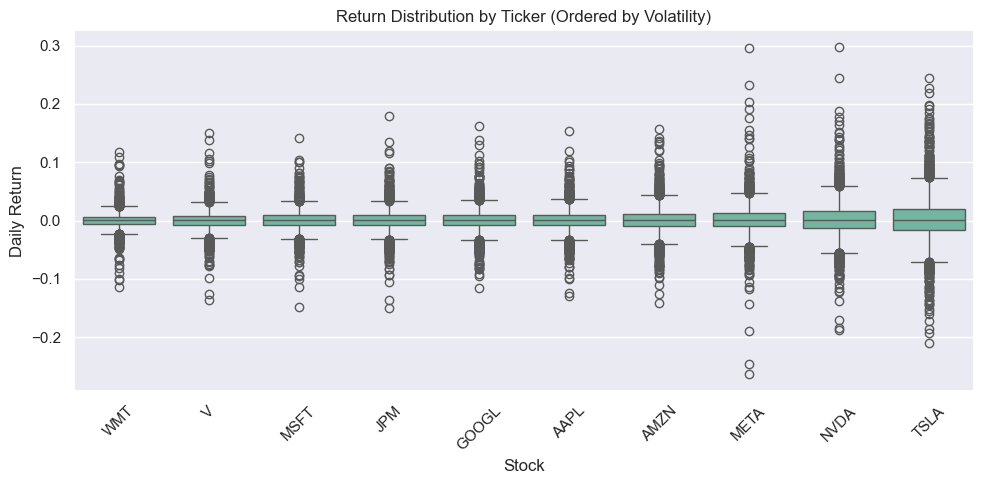

In [17]:
plot_return_boxplot(final_df)

Extreme return values are present across all stocks, which is expected in financial markets. However, the magnitude of these extremes differs across tickers. Growth-oriented stocks such as TSLA and NVDA exhibit wider distributions and more pronounced outliers, indicating higher volatility, while defensive stocks like WMT and V show more stable behavior. These differences are important for both predictive modeling and risk management.

In [18]:
top_gains = final_df.sort_values("Return", ascending=False).head(3)
top_losses = final_df.sort_values("Return", ascending=True).head(3)

In [19]:
extreme_events = pd.concat([top_gains, top_losses])
extreme_events.sort_values("Date")

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Return,Volatility_10d
28744,2013-05-09,4.626667,4.626667,5.051333,4.246000,4.674667,429075000,TSLA,0.243951,0.087018
16652,2013-07-25,34.092457,34.360001,34.880001,32.750000,33.540001,365457900,META,0.296115,0.093279
25663,2016-11-11,2.163087,2.199250,2.219250,1.962500,1.987750,2175344000,NVDA,0.298067,0.098582
30590,2020-09-08,110.070000,110.070000,122.913330,109.959999,118.666664,346397100,TSLA,-0.210628,0.093149
18800,2022-02-03,235.908707,237.759995,248.000000,235.750000,244.649994,188119900,META,-0.263901,0.087943
18984,2022-10-27,97.177406,97.940002,102.500000,96.379997,97.980003,232316600,META,-0.245571,0.085330


Analysis of the most extreme positive and negative returns revealed that these events align with major company-specific and macroeconomic developments, such as earnings announcements, strategic milestones, and market-wide shocks.

Large positive returns were primarily driven by strong earnings reports and significant business milestones. For instance:

- **NVIDIA (2016-11-11)** experienced a sharp increase following an earnings beat driven by strong **demand in gaming** and data center segments ([CNBC](https://www.cnbc.com/2016/11/10/nvidia-shares-spike-after-reporting-earnings-revenue-beat-firm-raises-dividend-buyback.html)).

- **Meta (2013-07-25)** surged after **reporting strong growth** in mobile advertising, which significantly improved investor confidence ([Business Insider](https://www.businessinsider.com/facebook-mobile-revenue-growth-2013-7)).

- **Tesla (2013-05-09)** saw a substantial rise after **reporting** its first-ever **profitable quarter**, marking a major milestone for the company ([Reuters](https://www.reuters.com/article/business/environment/tesla-stock-jumps-31-after-record-562m-in-sales-and-first-ever-quarterly-profi-idUS3607429561/)).

On the other hand, extreme negative returns were associated with disappointing financial results and strong market reactions:

- **Meta (2022-02-03)** experienced one of the largest single-day losses in market history following weak earnings, **slowing user growth**, and the impact of Apple’s privacy changes ([CNBC](https://www.cnbc.com/2022/02/02/stock-market-futures-open-to-close-news.html)).

- **Meta (2022-10-27)** declined again due to falling advertising revenue and continued high investment in **long-term** metaverse **initiatives** ([The Guardian](https://www.theguardian.com/technology/2022/oct/26/meta-earnings-report-facebook-stocks)).

- **Tesla (2020-09-08)** dropped sharply after being unexpectedly **excluded from the S&P 500** index, triggering a market correction ([CNBC](https://www.cnbc.com/2020/09/08/tesla-shares-slump-10percent-in-premarket-trading-after-sp-500-snub.html)).

These findings confirm that extreme values in the dataset reflect genuine financial events rather than data errors, supporting the decision to retain them in the analysis.

**Additional insight:** The return distribution exhibits heavy tails, indicating the presence of extreme market movements typical in financial time series.

**Ordering**

In [20]:
final_df.groupby("Ticker")["Date"].is_monotonic_increasing.all()

np.True_

In [21]:
for ticker, df_ticker in final_df.groupby("Ticker"):
    print(ticker)
    print(df_ticker["Date"].iloc[0], "→", df_ticker["Date"].iloc[-1])

AAPL
2010-01-19 00:00:00 → 2026-04-07 00:00:00
AMZN
2010-01-19 00:00:00 → 2026-04-07 00:00:00
GOOGL
2010-01-19 00:00:00 → 2026-04-07 00:00:00
JPM
2010-01-19 00:00:00 → 2026-04-07 00:00:00
META
2012-06-04 00:00:00 → 2026-04-07 00:00:00
MSFT
2010-01-19 00:00:00 → 2026-04-07 00:00:00
NVDA
2010-01-19 00:00:00 → 2026-04-07 00:00:00
TSLA
2010-07-14 00:00:00 → 2026-04-07 00:00:00
V
2010-01-19 00:00:00 → 2026-04-07 00:00:00
WMT
2010-01-19 00:00:00 → 2026-04-07 00:00:00


---
# 3. Exploratory Data Analysis (EDA)

## 3.1 Objective of EDA

The exploratory analysis aims to understand return behavior, volatility patterns, and cross-stock relationships prior to modeling. This step helps identify distribution characteristics, risk differences, and structural properties relevant for forecasting, survival analysis, and ranking tasks.

**Key findings from EDA:**

- TSLA and NVDA exhibit the highest average returns but also substantially higher volatility
- WMT and V show lower volatility and more stable return profiles
- Returns are centered around zero with heavy tails and extreme movements
- Technology stocks display stronger co-movement compared to defensive assets
- Volatility varies across time, with noticeable spikes during market stress periods

## 3.2 Return Distribution Analysis

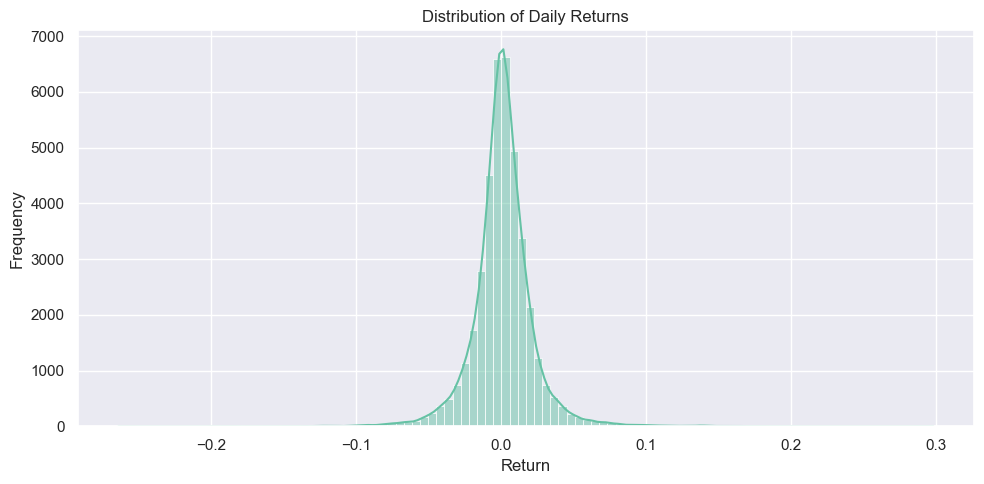

In [22]:
plot_return_histogram(final_df)

The distribution of daily returns is centered around zero, with most observations concentrated near small movements. However, the distribution exhibits heavy tails, indicating the presence of extreme market events. This behavior is typical for financial time series and suggests that returns are not normally distributed.

**Average return per stock**

In [23]:
avg_returns = final_df.groupby("Ticker")["Return"].mean().sort_values()

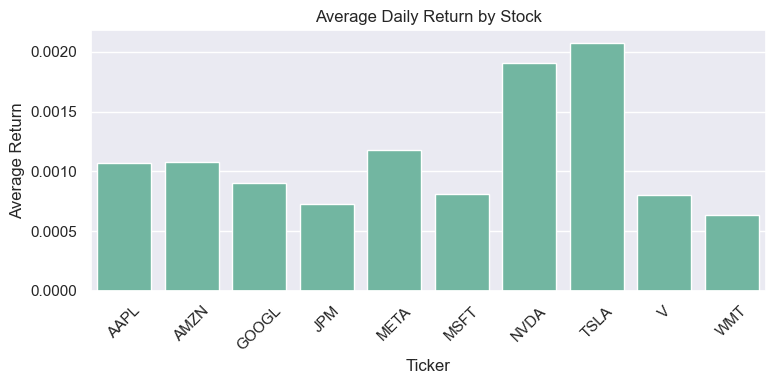

In [24]:
plot_average_returns(final_df)

Average daily returns vary across stocks, with values ranging from approximately 0.0006 (WMT) to over 0.002 (TSLA). Growth-oriented companies such as TSLA and NVDA tend to generate higher returns on average, while defensive stocks exhibit smaller but more stable performance.

Higher returns are generally accompanied by increased volatility, reflecting the classic risk–return trade-off observed in financial markets.

**Price Trends Over Time**

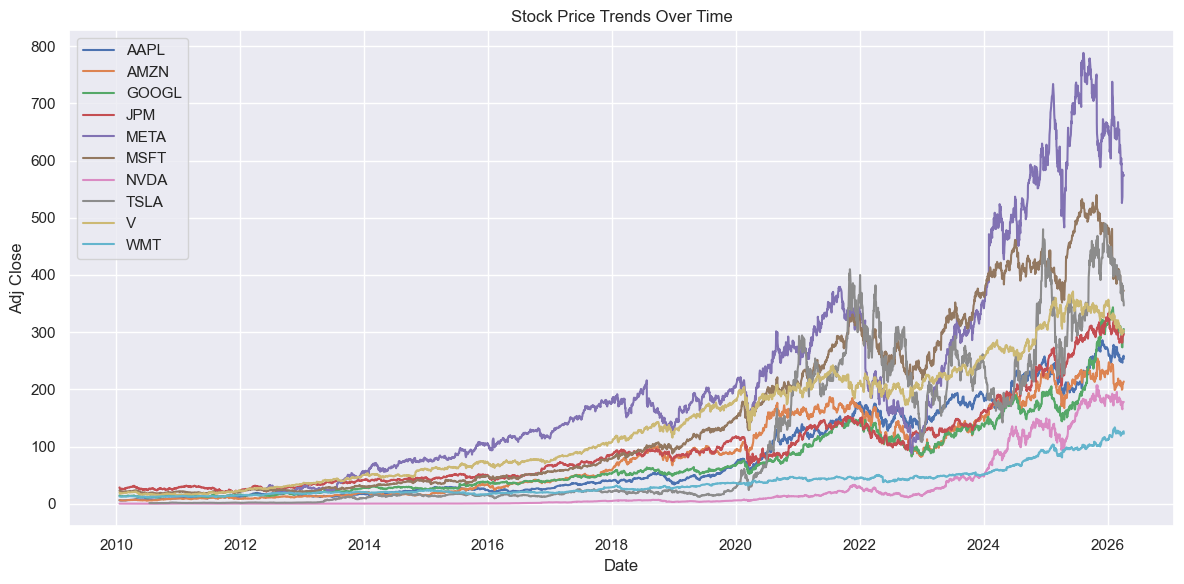

In [25]:
plot_price_trends(final_df)

Price trends show substantial long-term growth across most stocks, particularly among large technology companies. NVIDIA, Tesla, Microsoft, and Meta display the strongest upward trajectories, but also exhibit larger fluctuations.

More defensive companies such as Walmart and Visa show steadier and more gradual growth patterns, with lower volatility. Financial stocks such as JPMorgan fall between these two behaviors.

A noticeable market-wide decline appears around 2020–2022, followed by a recovery period. Overall, the data reflects long-term market expansion together with periods of elevated uncertainty and volatility.

## 3.3 Volatility Analysis
To compare risk levels across stocks, 10-day rolling volatility was computed for each ticker.  
This measure captures short-term variability in returns and highlights differences in market risk.


**Average return per stock**

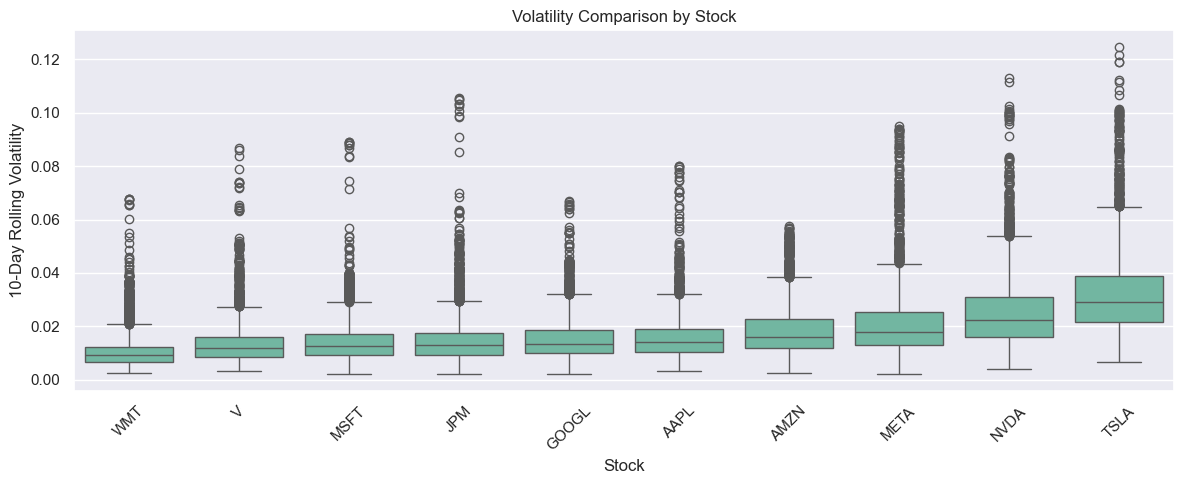

In [26]:
plot_volatility_boxplot(final_df)

The volatility distribution differs substantially across stocks. Growth-oriented stocks such as TSLA and NVDA exhibit the widest distributions and highest volatility levels, indicating larger and more frequent price movements. In contrast, defensive stocks such as WMT and V show narrower distributions and lower volatility, suggesting more stable behavior.

To further examine temporal patterns, rolling volatility was plotted over time for each ticker.

**Volatility Over Time**

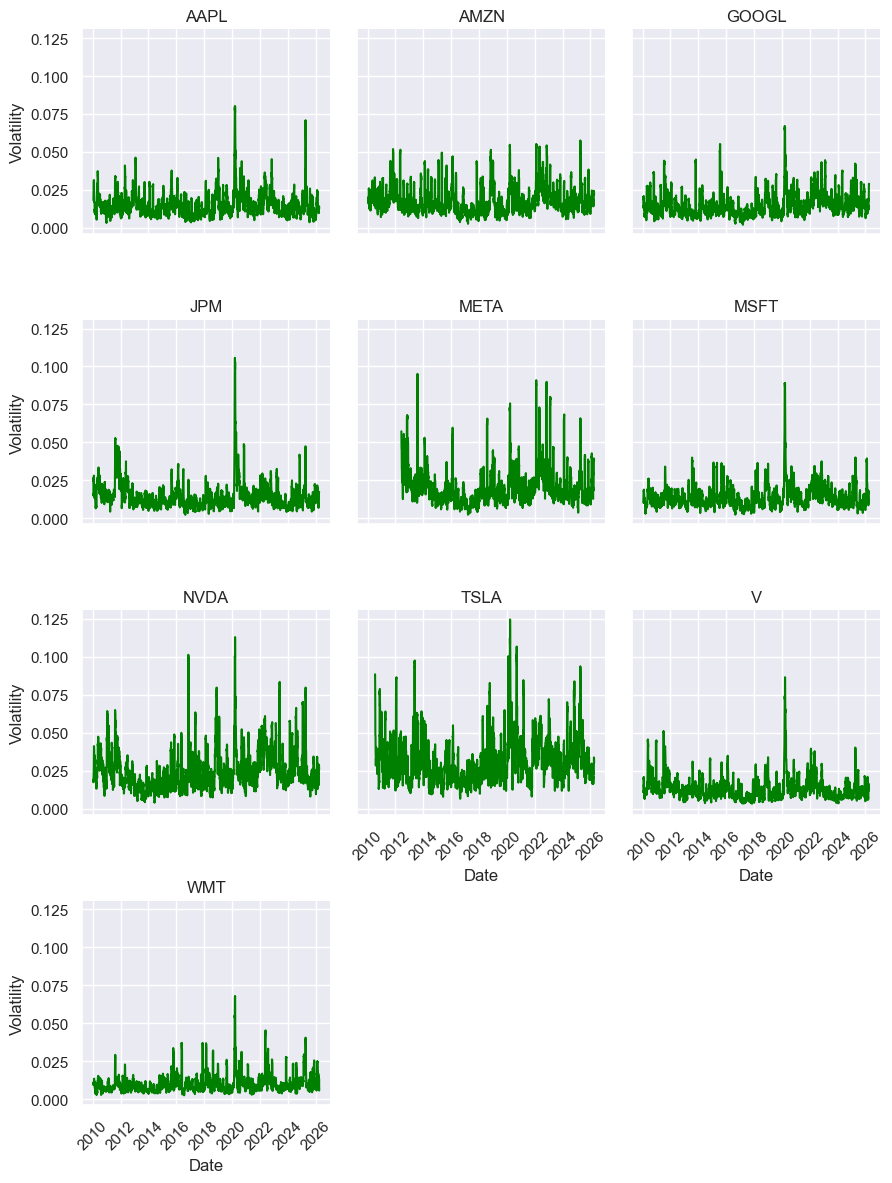

In [27]:
plot_volatility_facets(final_df)

The time-series plots reveal that volatility is not constant but occurs in clusters. Periods of calm market behavior are followed by episodes of elevated volatility, particularly during market-wide events. This pattern is especially pronounced for TSLA, NVDA, and META, while WMT and V remain comparatively stable.

These findings confirm that stocks exhibit distinct risk profiles and that volatility clustering is present in the data. This has important implications for forecasting accuracy, survival modeling of extreme events, and ranking-based portfolio decisions.

## 3.4 Volatility Clustering Analysis

The autocorrelation analysis shows that raw returns exhibit little serial correlation, indicating limited predictability in directional price movements. However, squared returns display significant autocorrelation, suggesting volatility clustering. This implies that periods of high volatility tend to be followed by further high volatility, which supports the use of rolling volatility features in subsequent modeling.

**TSLA** and **WMT** were selected as representative examples of high-volatility and low-volatility stocks, allowing comparison of autocorrelation behavior across contrasting risk profiles.

In [28]:
tsla = final_df.loc[final_df["Ticker"] == "TSLA", "Return"].dropna()
wmt = final_df.loc[final_df["Ticker"] == "WMT", "Return"].dropna()

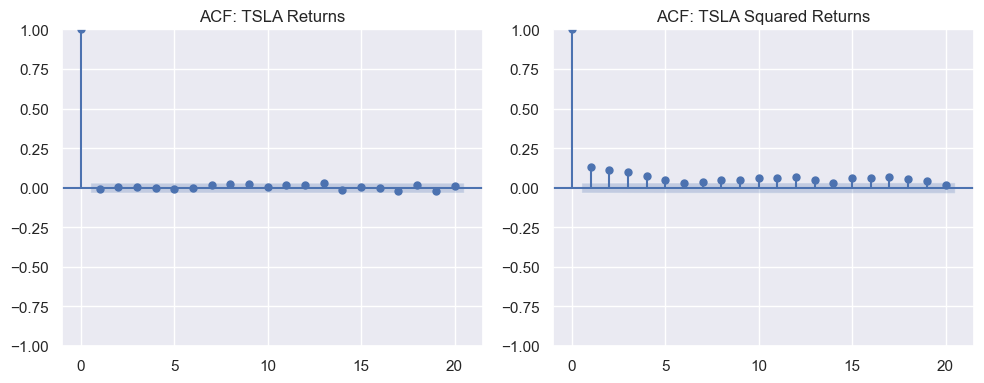

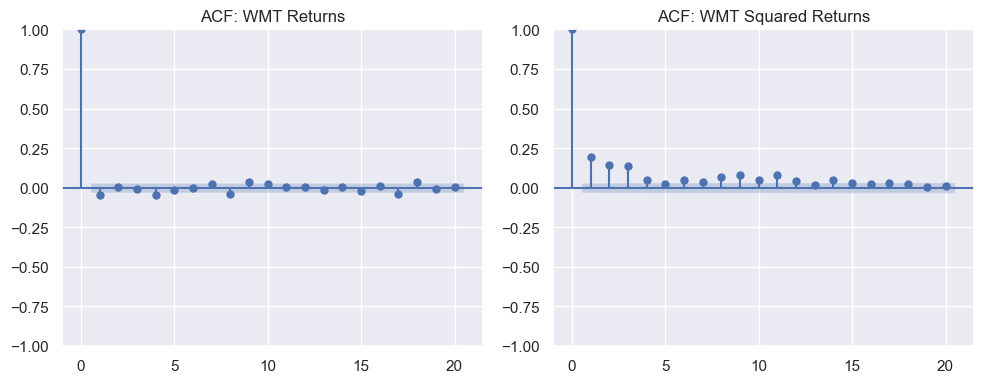

In [29]:
plot_return_acf_pair(final_df, "TSLA")
plot_return_acf_pair(final_df, "WMT")

<table align="left">
<tr><th>Stock</th><th>Return Predictability</th><th>Volatility Clustering</th><th>Risk Profile</th></tr>
<tr><td>TSLA</td><td>Weak</td><td>Strong</td><td>High volatility</td></tr>
<tr><td>WMT</td><td>Weak</td><td>Moderate</td><td>More stable</td></tr>
</table>

<br clear="all">


## 3.5 Ljung–Box Test
The Ljung–Box test confirms that raw returns do not exhibit significant autocorrelation, while squared returns show statistically significant dependence, supporting the presence of volatility clustering.

**(H0)**: No autocorrelation (series is white noise) p > 0.05   
**(H1)**: Autocorrelation exists

In [30]:
tsla = final_df.loc[final_df["Ticker"]=="TSLA","Return"].dropna()

acorr_ljungbox(tsla, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,5.648743,0.843861


In [31]:
acorr_ljungbox(tsla**2, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,230.233486,7.673567e-44


**Fail to reject the null hypothesis**, **returns** are not serially correlated and are difficult to predict.  
**Reject the null hypothesis**, **squared returns** exhibit significant autocorrelation, indicating volatility clustering.

## 3.6 Correlation & Diversification

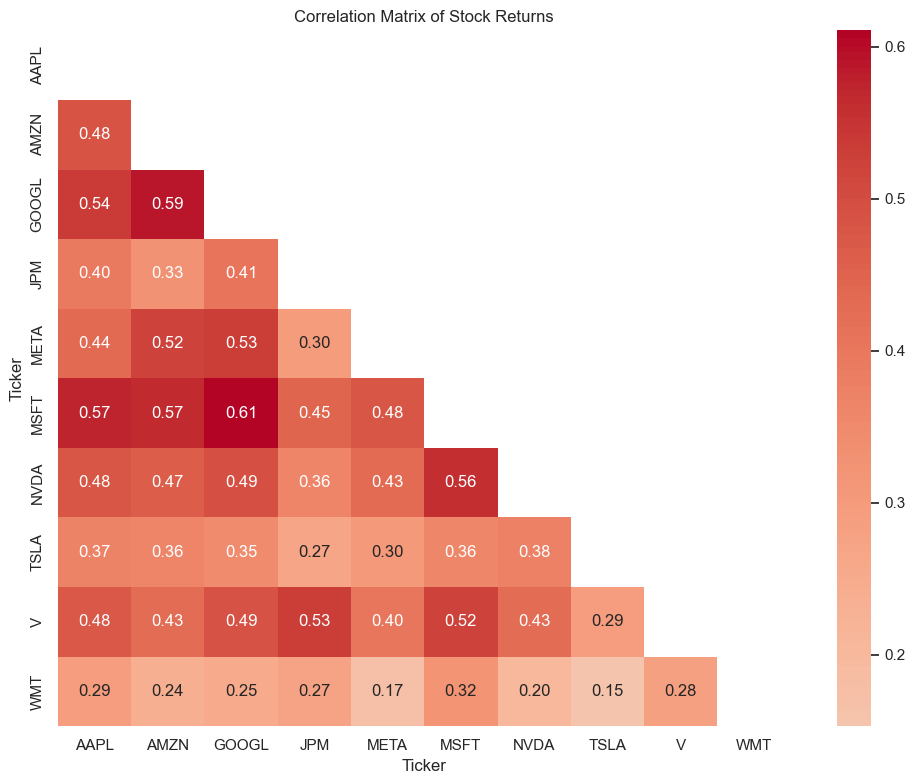

In [32]:
plot_return_correlation_heatmap(final_df)

The correlation matrix shows that most stocks exhibit moderate positive correlations, typically ranging between 0.3 and 0.6, indicating that they tend to move in the same direction.

Technology stocks such as Apple, Microsoft, Google, and NVIDIA show relatively stronger correlations with each other, reflecting shared exposure to similar industry and macroeconomic factors.

In contrast, stocks like Walmart exhibit lower correlations with other companies, suggesting more independent price behavior.

Although correlations are generally positive, they are far from perfect, indicating that diversification benefits can still be achieved by combining different assets within a portfolio.

## 3.7 Risk Analysis (Value at Risk)

In [33]:
tsla = final_df.loc[final_df["Ticker"]=="TSLA","Return"].dropna()
wmt  = final_df.loc[final_df["Ticker"]=="WMT","Return"].dropna()

var_95_tsla = np.percentile(tsla, 5)
var_95_wmt  = np.percentile(wmt, 5)

print(f"TSLA VaR(95%): {var_95_tsla:.4f}")
print(f"WMT  VaR(95%): {var_95_wmt:.4f}")

TSLA VaR(95%): -0.0512
WMT  VaR(95%): -0.0172


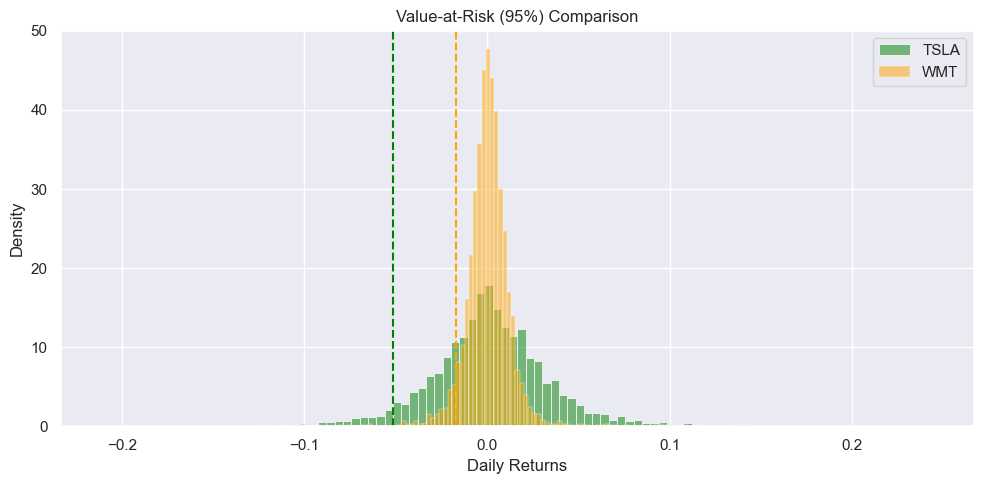

In [34]:
plot_var_comparison(tsla, wmt, var_95_tsla, var_95_wmt)

The 95% Value-at-Risk indicates substantially higher downside risk for TSLA (−5.12%) compared to WMT (−1.71%). This confirms that TSLA exhibits heavier tail losses and greater volatility, while WMT behaves as a more stable, lower-risk asset.

## 3.8 Risk–Return Summary by Ticker

To support portfolio-oriented interpretation, stocks were compared not only on raw returns but also on volatility and a simple return-to-risk measure.

In [35]:
summary = final_df.groupby("Ticker").agg(
    mean_return=("Return", "mean"),
    std_return=("Return", "std"),
    avg_volatility=("Volatility_10d", "mean")
)

summary["return_to_risk"] = summary["mean_return"] / summary["std_return"]

summary = summary.sort_values("return_to_risk", ascending=False)

summary

,mean_return,std_return,avg_volatility,return_to_risk
Ticker,,,,
NVDA,0.001910,0.028718,0.025483,0.066502
AAPL,0.001068,0.017725,0.015771,0.060271
TSLA,0.002076,0.036045,0.032540,0.057588
AMZN,0.001075,0.020668,0.018555,0.052017
GOOGL,0.000900,0.017422,0.015582,0.051682
V,0.000799,0.015650,0.013725,0.051056
WMT,0.000631,0.012423,0.010701,0.050783
MSFT,0.000813,0.016150,0.014379,0.050345
META,0.001182,0.024831,0.021273,0.047581


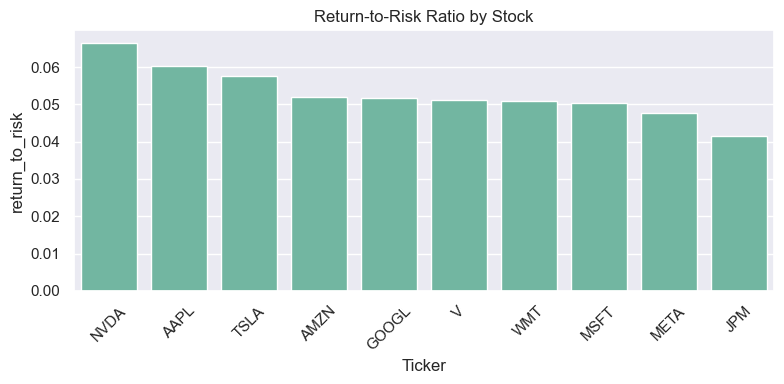

In [36]:
plot_return_to_risk_ratio(summary)

The results show that NVIDIA and Apple achieve the highest return-to-risk ratios, indicating strong performance relative to their volatility.

While Tesla and Amazon exhibit higher absolute returns, their elevated volatility reduces their risk-adjusted efficiency.

More stable stocks such as Visa and Walmart provide lower returns but also significantly lower risk, making them suitable for conservative portfolio strategies.

Overall, the return-to-risk metric highlights that the best-performing stocks are not necessarily those with the highest returns, but those that balance return and volatility effectively.

## 3.9 Interpretation of Risk–Return Trade-off

To better understand investment characteristics, stocks were compared based on average return, volatility, and a simple return-to-risk ratio.

The results show that high-growth stocks such as NVDA and TSLA tend to offer higher returns but also exhibit higher volatility. In contrast, defensive stocks like WMT and V show lower volatility and more stable returns.

This highlights the classic risk–return trade-off: higher expected returns are associated with higher risk.

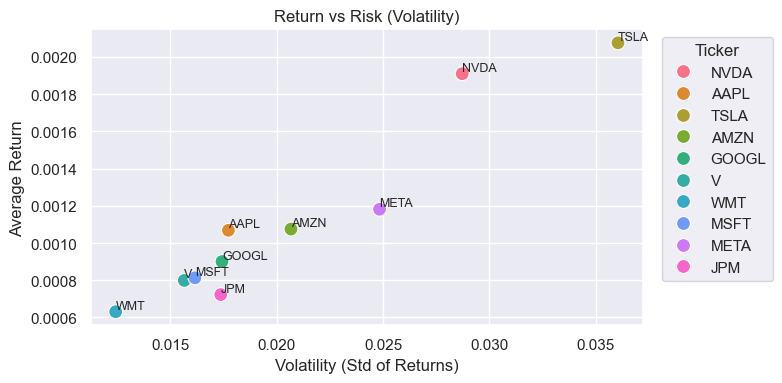

In [37]:
sns.set_theme(style="darkgrid", palette="Set2")
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=summary,
    x="std_return",
    y="mean_return",
    hue=summary.index, 
    s=100
)

for ticker in summary.index:
    plt.text(
        summary.loc[ticker, "std_return"],
        summary.loc[ticker, "mean_return"],
        ticker,
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.title("Return vs Risk (Volatility)")
plt.xlabel("Volatility (Std of Returns)")
plt.ylabel("Average Return")

plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3.10 Subperiod Analysis
To evaluate whether stock behavior is stable over time, the data was divided into three distinct market periods:

- **2010–2019**: Pre-COVID stable growth period  
- **2020–2022**: High-volatility regime (COVID + macro shocks)  
- **2023–Present**: Recent market normalization  

This allows us to assess whether return and risk characteristics remain consistent across different market conditions.

In [38]:
df_period = final_df.copy()

df_period["Period"] = pd.cut(
    df_period["Date"].dt.year,
    bins=[2009, 2019, 2022, 2030],
    labels=["2010-2019", "2020-2022", "2023-present"]
)

period_summary = df_period.groupby(["Period", "Ticker"]).agg(
    mean_return=("Return", "mean"),
    volatility=("Return", "std")
).reset_index()

#period_summary

In [39]:
pivot_table = period_summary.pivot(
    index="Ticker",
    columns="Period",
    values="volatility"
)

pivot_table

Period,2010-2019,2020-2022,2023-present
Ticker,,,
AAPL,0.016235,0.023264,0.016129
AMZN,0.019519,0.024624,0.020079
GOOGL,0.015335,0.021747,0.018883
JPM,0.015788,0.023854,0.014659
META,0.022374,0.030683,0.024200
MSFT,0.014325,0.021890,0.015172
NVDA,0.025566,0.035245,0.031022
TSLA,0.032079,0.045454,0.037160
V,0.014765,0.021078,0.011975


The subperiod analysis shows a clear increase in volatility during the 2020–2022 period, reflecting heightened market uncertainty. This pattern is consistent across most stocks, indicating a broad market-wide effect. Growth-oriented stocks such as **NVDA** and **TSLA** exhibit substantially higher volatility compared to other assets, confirming their higher risk profile and sensitivity to market conditions. In contrast, more defensive stocks such as **WMT** and **V** display lower overall volatility, although they are still affected by broader market shifts. Overall, volatility is not stable across time, suggesting that market risk varies significantly across periods and should be accounted for in modeling and portfolio decisions.

---
# 4. Statistical Inference
**Target population**: Daily returns of selected large-cap stocks from 2010 to present.

**Significance level**: α = 0.05

**Hypotheses tested**:

1. **Mean return difference**
- *H0*: μ₁ = μ₂
- *H1*: μ₁ ≠ μ₂
2. **Volatility difference**
- *H0*: σ₁ = σ₂
- *H1*: σ₁ ≠ σ₂
3. **Proportion of positive returns**
- *H0*: p₁ = p₂
- *H1*: p₁ ≠ p₂

Normality was assessed visually and/or via statistical tests. Where normality assumptions were not met, non-parametric tests were preferred.

## 4.1 Tesla vs Walmart Mean Return Comparison
**Question**: Do Tesla and Walmart have different average daily returns?  
Tesla (TSLA) and Walmart (WMT) were selected as representative examples of:

- **High-growth, high-volatility stock (TSLA)**
- **Defensive, stable stock (WMT)**

This comparison illustrates how return behavior differs across business models.

However, this pairwise analysis is used as an **illustrative example**, not as a general conclusion for all stocks.

**H0**: μ_TSLA = μ_WMT  
**H1**: μ_TSLA ≠ μ_WMT

**Test used**: **Welch t-test**  
**Reason**: Return distributions are not perfectly normal, and group variances may differ. Welch’s t-test is more robust than the standard independent t-test when variances are unequal.

**Result**:  
t = 2.38, p = 0.017

**Conclusion**:  
Since p < 0.05, we reject the null hypothesis.  
Tesla and Walmart show a statistically significant difference in average daily returns.

In [40]:
tsla = final_df.loc[final_df["Ticker"] == "TSLA", "Return"].dropna()
wmt = final_df.loc[final_df["Ticker"] == "WMT", "Return"].dropna()

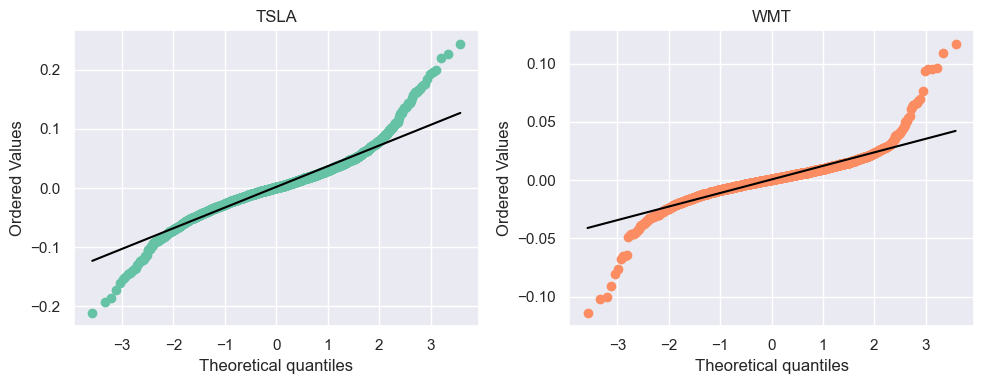

In [41]:
plot_qq_comparison(tsla, wmt)

The QQ plots indicate that daily stock returns deviate from the normal distribution. TSLA shows strong curvature, particularly in the tails, indicating heavy-tailed behavior and frequent extreme movements. WMT exhibits a distribution closer to normality, though deviations are still present. These results suggest that the assumption of normality does not hold, particularly for more volatile stocks, supporting the use of non-parametric statistical methods.

In [42]:
sample_tsla = final_df.loc[final_df["Ticker"] == "TSLA", "Return"].dropna().sample(500, random_state=42)
sample_wmt = final_df.loc[final_df["Ticker"] == "WMT", "Return"].dropna().sample(500, random_state=42)

print(stats.shapiro(sample_tsla))
print(stats.shapiro(sample_wmt))

ShapiroResult(statistic=np.float64(0.9023108964094217), pvalue=np.float64(2.330116436124993e-17))
ShapiroResult(statistic=np.float64(0.827339790263465), pvalue=np.float64(8.031204882562491e-23))


In [43]:
tsla = final_df[final_df["Ticker"] == "TSLA"]["Return"]
wmt = final_df[final_df["Ticker"] == "WMT"]["Return"]

t_stat, p_value = stats.ttest_ind(tsla, wmt, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 2.387693793384736
p-value: 0.01699245929725331


In [44]:
stat, p_value = mannwhitneyu(tsla, wmt)
print(stat, p_value)

8216803.0 0.1588223465523546


The **QQ plot** indicates that while the central portion of the return distribution **roughly** follows a **normal pattern**, there are clear deviations in the tails. Both lower and upper tails diverge from the theoretical normal line, indicating the presence of **heavy tails**.

To formally assess normality, the **Shapiro–Wilk** test was applied. For both Tesla and Walmart, the **p-values** were **significantly below 0.05**, leading to **rejection of the null hypothesis of normality**. This confirms that return distributions are not normally distributed.

Given this, a **Welch t-test** was used to compare mean returns, as it is robust to unequal variances. The test produced a **p-value of 0.017**, indicating a **statistically significant difference** between Tesla and Walmart returns.

However, given the relatively small magnitude of daily returns, the practical difference may be modest despite being statistically significant.

As a robustness check, a **Mann–Whitney U** test was also conducted, which does **not assume normality**. The test did not find a statistically significant difference at the 5% level, suggesting that while mean returns differ, the overall distributional differences may be less pronounced.

### 4.2 Confidence Interval for Mean Return Difference

To quantify the difference in average returns, a 95% confidence interval for the difference between Tesla and Walmart mean daily returns was computed.

**Result**:  
Mean difference = 0.001445  
95% CI = [0.000259, 0.002631]

**Conclusion**:  
Since the confidence interval does not include zero, this provides statistical evidence that Tesla has a higher average daily return than Walmart.

However, while the difference is statistically significant, the magnitude of the difference is relatively small in absolute terms. This highlights the distinction between statistical significance and practical significance in financial data.

In [45]:
diff = tsla.mean() - wmt.mean()

se = np.sqrt(
    tsla.var()/len(tsla) +
    wmt.var()/len(wmt)
)

ci_diff = stats.t.interval(
    0.95,
    df=min(len(tsla), len(wmt)) - 1,
    loc=diff,
    scale=se
)

print("Mean difference:", diff)
print("95% CI (difference):", ci_diff)

Mean difference: 0.0014448391447913118
95% CI (difference): (np.float64(0.0002584645041585228), np.float64(0.002631213785424101))


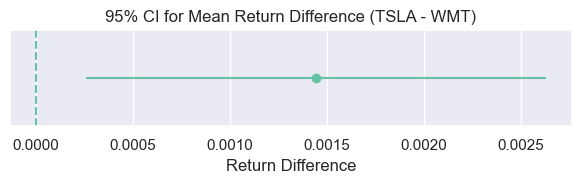

In [46]:
mean_diff = 0.001445
ci_low =  0.000258
ci_high = 0.002631
plot_mean_difference_ci(mean_diff, ci_low, ci_high)

## 4.3 Volatility Difference (Tesla vs Walmart)

**Question**: Do Tesla and Walmart differ in their volatility levels?

**H0**: The volatility distributions of Tesla and Walmart are equal  
**H1**: The volatility distributions of Tesla and Walmart differ  

**Test used**: **Mann–Whitney U test**  
**Reason**: Volatility is not normally distributed, and the test does not assume normality.

**Result**:  
U = 15399383.0, p = 0.001  

**Conclusion**:  
p < 0.05, we reject the null hypothesis and conclude that Tesla and Walmart have significantly different volatility levels.  
This result confirms the findings from exploratory analysis, where Tesla exhibited higher volatility compared to Walmart, reflecting its higher-risk profile.

In [47]:
tsla_vol = final_df[final_df["Ticker"] == "TSLA"]["Volatility_10d"]
wmt_vol = final_df[final_df["Ticker"] == "WMT"]["Volatility_10d"]

stat, p_value = mannwhitneyu(tsla_vol, wmt_vol)

print("U-stat:", stat)
print("p-value:", p_value)

U-stat: 15399378.0
p-value: 0.0


## 4.4 Proportion of Positive Returns

**Question**: Is the proportion of positive daily returns equal to 50%?

**H0**: p = 0.5  
**H1**: p ≠ 0.5  

**Test used**: **One-sample proportion z-test**  
**Reason**: The test evaluates whether the observed proportion of positive returns differs from a specified benchmark (50%).

**Result**:  
z = 10.94  
p < 0.001  

**Conclusion**:  
Since p < 0.05, we reject the null hypothesis and conclude that the proportion of positive returns is significantly different from 50%.

This suggests that stock returns are not equally likely to be positive or negative, indicating a slight directional bias in the market over the observed period.

In [48]:
returns = final_df["Return"] > 0

successes = returns.sum()
n = len(returns)

z_stat, p_value = proportions_ztest(successes, n, value=0.5)

print("z-stat:", z_stat)
print("p-value:", p_value)

z-stat: 10.941891227809258
p-value: 7.26679922077419e-28


In [49]:
prop = successes / n

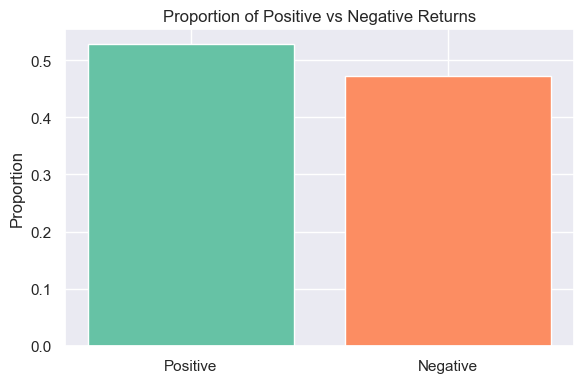

In [50]:
plot_positive_negative_proportion(prop)

The observed proportion of positive returns is approximately 53%, indicating that positive returns occur slightly more frequently than negative ones.

While this difference is statistically significant, the magnitude is relatively small, suggesting that daily market movements remain largely unpredictable despite a slight upward tendency.

### 4.4 Group-Level Volatility Comparison (Growth vs Defensive)

**Business motivation**:  
In practice, investors are less interested in comparing individual stocks and more interested in understanding whether different **types of stocks** behave differently.  

High-growth companies are typically expected to exhibit higher volatility compared to defensive, stable companies. This has direct implications for portfolio construction and risk management.

**Group definition**:

- **High-growth stocks**: TSLA, NVDA, META  
- **Defensive / stable stocks**: WMT, JPM, V  

**Question**:  
Do high-growth stocks exhibit higher volatility than defensive stocks?

**H0**: Volatility of high-growth stocks = volatility of defensive stocks  
**H1**: Volatility differs between the groups  

**Test used**: **Mann–Whitney U test**  
**Reason**: Volatility distributions are non-normal and heteroskedastic, making non-parametric tests more appropriate.


**Result**:  
U = 118371500.0   
p < 0.001

**Conclusion**:  
Since p < 0.05, we reject the null hypothesis and conclude that volatility differs significantly between high-growth and defensive stocks.

The extremely small p-value indicates a strong statistical difference between the groups. This result supports the expectation that high-growth stocks exhibit higher volatility compared to defensive stocks, reinforcing the presence of a risk–return trade-off in financial markets.

**Note**:  
Group definitions are illustrative and based on typical market classification; results should be interpreted accordingly.

In [51]:
growth = final_df[final_df["Ticker"].isin(["TSLA", "NVDA", "META"])]["Volatility_10d"]
defensive = final_df[final_df["Ticker"].isin(["WMT", "JPM", "V"])]["Volatility_10d"]

stat, p_value = mannwhitneyu(growth, defensive)

print("U-stat:", stat)
print("p-value:", p_value)

U-stat: 118371468.0
p-value: 0.0


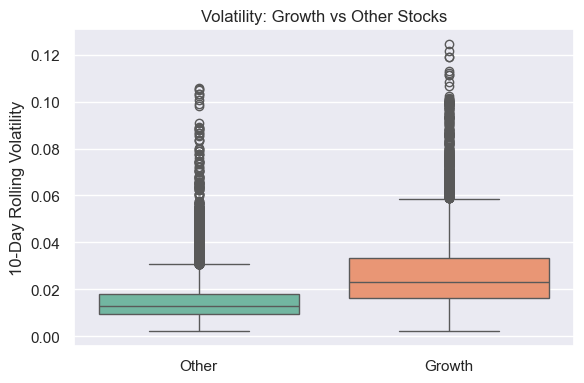

In [52]:
plot_growth_vs_other_volatility(final_df)

## 4.5 Proportion of Positive Returns by Ticker

Although return distributions are non-normal, the positive-return test is based on binary outcomes (positive vs negative days).

This allows the use of a proportion z-test, which relies on binomial assumptions rather than normality of returns.

Therefore, the test remains appropriate for evaluating whether the probability of a positive return differs from 50%.
However, results should be interpreted with caution due to potential time dependence in financial data.

In [53]:
results = []

for ticker in final_df["Ticker"].unique():
    r = final_df.loc[final_df["Ticker"] == ticker, "Return"] > 0
    successes = r.sum()
    n = len(r)
    z_stat, p_value = proportions_ztest(successes, n, value=0.5)

    results.append({
        "Ticker": ticker,
        "Positive_Proportion": successes / n,
        "z_stat": z_stat,
        "p_value": p_value
    })

prop_results = pd.DataFrame(results).sort_values("Positive_Proportion", ascending=False)
prop_results

,Ticker,Positive_Proportion,z_stat,p_value
8,V,0.540574,5.199789,1.995144e-07
9,WMT,0.532729,4.189544,2.795150e-05
0,AAPL,0.530522,3.906009,9.383320e-05
2,GOOGL,0.529787,3.811548,1.380990e-04
6,NVDA,0.529051,3.717113,2.015121e-04
1,AMZN,0.527580,3.528315,4.182137e-04
5,MSFT,0.522922,2.931039,3.378302e-03
4,META,0.522414,2.647109,8.118325e-03
3,JPM,0.519980,2.554217,1.064269e-02
7,TSLA,0.516300,2.051812,4.018793e-02


The results show that all stocks exhibit a proportion of positive returns slightly above 50%, ranging from approximately 51.6% (TSLA) to 54.0% (V).

For all tickers, the null hypothesis (p = 0.5) is rejected at the 5% level, indicating that positive returns occur more frequently than negative ones.

However, the magnitude of this difference is relatively small, suggesting that while markets show a slight upward bias, daily returns remain largely unpredictable.

---
# 5. Forecasting Models
The model predicts next-day returns instead of raw price levels. This is standard in financial modeling, as returns are more stationary, comparable across assets, and more suitable for machine learning models. Predicted returns can be directly translated into expected price movements.

## 5.1 Forecasting Objective
The objective of this section is to predict next-day stock returns using historical information.

This problem is framed as a supervised learning task, where lagged returns and short-term rolling statistics are used as predictors of the following day’s return.

Since this is time-series data, a chronological split was used to avoid data leakage. The dataset was split chronologically into training and testing periods to preserve temporal ordering and avoid look-ahead bias. This ensures that the model only uses past information when predicting future returns, which is essential for realistic financial evaluation.
The dataset was divided into:

- **Training set**(70%): earliest period
- **Validation set**(15%): intermediate period
- **Test set**(15%): most recent period

All feature engineering (e.g., rolling statistics, lagged variables) was constructed using only past information.
Model selection and tuning were performed on the validation set, and final evaluation was conducted on the test set only.

### Feature Engineering

In [54]:
df_model = final_df.copy()

# forecasting target: next-day return
df_model["target_return_next"] = (
    df_model.groupby("Ticker")["Return"].shift(-1)
)

# actual next-day closing price
df_model["Close_next"] = (
    df_model.groupby("Ticker")["Close"].shift(-1)
)

df_model["lag_1"] = df_model.groupby("Ticker")["Return"].shift(1)
df_model["lag_2"] = df_model.groupby("Ticker")["Return"].shift(2)
df_model["lag_5"] = df_model.groupby("Ticker")["Return"].shift(5)

# rolling features based only on past information
df_model["rolling_mean_5"] = (
    df_model.groupby("Ticker")["Return"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

df_model["rolling_std_5"] = (
    df_model.groupby("Ticker")["Return"]
    .transform(lambda x: x.shift(1).rolling(5).std())
)

df_model["rolling_std_10"] = (
    df_model.groupby("Ticker")["Return"]
    .transform(lambda x: x.shift(1).rolling(10).std())
)

df_model["rolling_std_20"] = (
    df_model.groupby("Ticker")["Return"]
    .transform(lambda x: x.shift(1).rolling(20).std())
)

df_model["abs_return_lag_1"] = (
    df_model.groupby("Ticker")["Return"].shift(1).abs()
)

df_model = df_model.dropna()

features = [
    "lag_1",
    "lag_2",
    "lag_5",
    "rolling_mean_5",
    "rolling_std_5",
    "rolling_std_10",
    "rolling_std_20",
    "abs_return_lag_1"
]

train_list = []
val_list = []
test_list = []

for ticker, df_ticker in df_model.groupby("Ticker"):
    n = len(df_ticker)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    train_list.append(df_ticker.iloc[:train_end])
    val_list.append(df_ticker.iloc[train_end:val_end])
    test_list.append(df_ticker.iloc[val_end:])

df_train = pd.concat(train_list)
df_val = pd.concat(val_list)
df_test = pd.concat(test_list)

X_train = df_train[features]
y_train = df_train["target_return_next"]

X_val = df_val[features]
y_val = df_val["target_return_next"]

X_test = df_test[features]
y_test = df_test["target_return_next"]

## 5.2 Baseline Model
A naive persistence baseline was used as the first benchmark. In this approach, the next-day return is predicted as equal to the previous day’s return.

This baseline provides a simple reference point and helps determine whether more advanced models capture information beyond short-term persistence.

In [55]:
df_test["naive_pred"] = df_test["lag_1"]

baseline_mae = mean_absolute_error(df_test["Return"], df_test["naive_pred"])
print("Naive MAE:", baseline_mae)

Naive MAE: 0.02057233624397232


In [56]:
baseline_ticker_perf = df_test.groupby("Ticker").apply(
    lambda df: mean_absolute_error(df["Return"], df["naive_pred"])
)

baseline_ticker_perf

Ticker
AAPL     0.015579
AMZN     0.020127
GOOGL    0.019154
JPM      0.014596
META     0.023109
MSFT     0.015267
NVDA     0.032177
TSLA     0.039822
V        0.013035
WMT      0.013801
dtype: float64

## 5.3 Interpretable Statistical / Linear Model

An interpretable linear benchmark was included to assess whether a simple parametric model can capture next-day return patterns.

Ridge Regression was selected because it remains transparent while reducing instability caused by correlated lagged features.

In [57]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_val_preds = ridge.predict(X_val)
ridge_test_preds = ridge.predict(X_test)

ridge_val_mae = mean_absolute_error(y_val, ridge_val_preds)
ridge_test_mae = mean_absolute_error(y_test, ridge_test_preds)

print("Ridge Validation MAE:", ridge_val_mae)
print("Ridge Test MAE:", ridge_test_mae)

Ridge Validation MAE: 0.016638122055003687
Ridge Test MAE: 0.014128442404880629


In [58]:
df_test_ridge = df_test.copy()
df_test_ridge["ridge_pred"] = ridge_test_preds

ridge_ticker_perf = df_test_ridge.groupby("Ticker").apply(
    lambda df: mean_absolute_error(df["Return"], df["ridge_pred"])
)

ridge_ticker_perf

Ticker
AAPL     0.011147
AMZN     0.014034
GOOGL    0.013367
JPM      0.010153
META     0.015541
MSFT     0.010199
NVDA     0.022017
TSLA     0.027548
V        0.008540
WMT      0.009561
dtype: float64

## 5.4 Nonlinear Model

A Random Forest Regressor was used as the nonlinear model to capture more complex relationships between lagged returns and rolling statistics.

Unlike linear models, Random Forest can model nonlinear interactions and threshold effects without requiring manual transformation of predictors.

In [59]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

val_preds = model.predict(X_val)
val_mae = mean_absolute_error(y_val, val_preds)
print("Validation MAE:", val_mae)

test_preds = model.predict(X_test)
test_mae = mean_absolute_error(y_test, test_preds)
print("Test MAE:", test_mae)

df_test = df_test.copy()
df_test["pred"] = test_preds

ticker_perf = df_test.groupby("Ticker").apply(
    lambda df: mean_absolute_error(df["Return"], df["pred"])
)

ticker_perf

Validation MAE: 0.017067971946002524
Test MAE: 0.014551307683979154


Ticker
AAPL     0.011694
AMZN     0.014770
GOOGL    0.013640
JPM      0.010392
META     0.015937
MSFT     0.010495
NVDA     0.022860
TSLA     0.028171
V        0.008837
WMT      0.010059
dtype: float64

## 5.5 LightGBM Model

An additional gradient boosting model (LightGBM) was tested to evaluate whether more advanced nonlinear methods improve predictive performance.

The results were comparable to Random Forest and Ridge Regression, suggesting that the available features contain limited nonlinear signal.

This is consistent with financial return prediction, where noise dominates and model complexity does not always translate into better performance.

In [60]:
lgb = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

lgb.fit(X_train, y_train)

lgb_val_preds = lgb.predict(X_val)
lgb_test_preds = lgb.predict(X_test)

lgb_val_mae = mean_absolute_error(y_val, lgb_val_preds)
lgb_test_mae = mean_absolute_error(y_test, lgb_test_preds)

print("LGBM Validation MAE:", lgb_val_mae)
print("LGBM Test MAE:", lgb_test_mae)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000409 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 27896, number of used features: 8
[LightGBM] [Info] Start training from score 0.001193
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

## 5.6 LightGBM (Tuned)

In [61]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5]
}

lgb = LGBMRegressor(random_state=42)

search = RandomizedSearchCV(
    lgb,
    param_distributions=param_grid,
    n_iter=5,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("Best params:", search.best_params_)
print("Best CV score:", -search.best_score_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000487 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 18597, number of used features: 8
[LightGBM] [Info] Start training from score 0.001236
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [62]:
best_preds = search.best_estimator_.predict(X_test)
best_test_mae = mean_absolute_error(y_test, best_preds)

print("Tuned LGBM Test MAE:", best_test_mae)

Tuned LGBM Test MAE: 0.014137073560292188


## 5.7 Model Comparison

In [63]:
best_val_preds = best_model.predict(X_val)
best_val_mae = mean_absolute_error(y_val, best_val_preds)

In [64]:
df_val_baseline = df_val.copy()
df_val_baseline["naive_pred"] = df_val_baseline["lag_1"]
baseline_val_mae = mean_absolute_error(df_val_baseline["Return"], df_val_baseline["naive_pred"])

df_test_baseline = df_test.copy()
df_test_baseline["naive_pred"] = df_test_baseline["lag_1"]
baseline_test_mae = mean_absolute_error(df_test_baseline["Return"], df_test_baseline["naive_pred"])

best_val_preds = best_model.predict(X_val)
best_val_mae = mean_absolute_error(y_val, best_val_preds)

model_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Ridge Regression",
        "Random Forest",
        "LightGBM",
        "LightGBM (tuned)"
    ],
    "Validation_MAE": [
        baseline_val_mae,
        ridge_val_mae,
        val_mae,
        lgb_val_mae,
        best_val_mae
    ],
    "Test_MAE": [
        baseline_test_mae,
        ridge_test_mae,
        test_mae,
        lgb_test_mae,
        best_test_mae
    ]
})

model_comparison = model_comparison.round(5)
model_comparison

,Model,Validation_MAE,Test_MAE
0,Naive Baseline,0.02390,0.02057
1,Ridge Regression,0.01664,0.01413
2,Random Forest,0.01707,0.01455
3,LightGBM,0.01669,0.01417
4,LightGBM (tuned),0.01664,0.01414


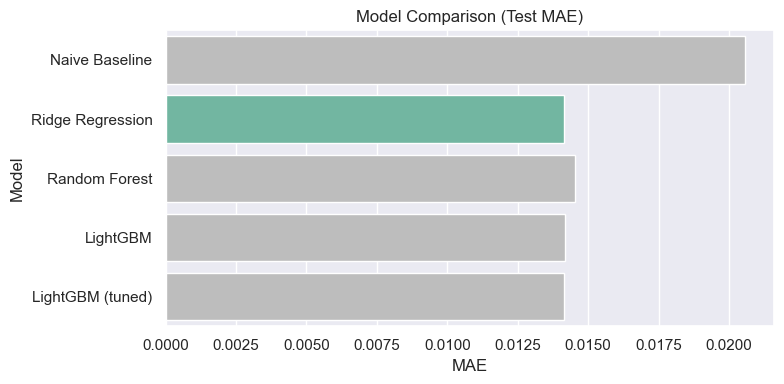

In [65]:
plot_model_comparison(model_comparison)

### Model Comparison Summary

The comparison shows that all machine learning models significantly outperform the naive persistence baseline, confirming that historical features contain useful predictive information.

**Ridge Regression** provides a substantial improvement over the baseline, reducing the test MAE from 0.02057 to 0.01413. More complex models such as Random Forest and LightGBM deliver only marginal additional gains, with performance differences remaining very small.

Among all models, Ridge Regression achieved the lowest test MAE, although LightGBM (tuned) produced nearly identical results. The minimal performance differences suggest that increased model complexity does not lead to meaningful improvements. Furthermore, additional hyperparameter tuning did not yield substantial gains, indicating that model performance is relatively insensitive to parameter choices.

Overall, these results indicate that short-term stock return prediction is constrained by a low signal-to-noise ratio. While machine learning models can extract some predictive signal, increasing model complexity yields only limited benefits.

This finding highlights the importance of complementing forecasting with ranking and risk-based approaches in practical financial applications.

*Because the performance differences between models are extremely small, additional statistical comparison of forecast errors could be performed in future work to determine whether any model consistently outperforms the others. However, given the minimal gaps observed, all models can be considered to have comparable predictive performance.*

In [66]:
model = ridge

### Walk-forward validation

In [67]:
tscv = TimeSeriesSplit(n_splits=5)

wf_scores = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = Ridge(alpha=1.0)
    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)
    wf_scores.append(mean_absolute_error(y_val, preds))

print(f"Walk-forward MAE: {np.mean(wf_scores):.5f} ± {np.std(wf_scores):.5f}")

Walk-forward MAE: 0.01374 ± 0.00397


Walk-forward validation produces an average MAE of  0.01374 ± 0.00397, which is consistent with the hold-out validation results.
This indicates that the model’s performance is relatively stable across different time periods, reducing the risk that results are driven by a specific market regime.

### Converting Return Forecasts to Price Predictions

The forecasting models are trained to predict next-day returns rather than raw prices. Predicting returns improves stationarity and allows a single generic model to be applied consistently across stocks with different price levels.

Predicted  next-day stock price returns are converted into implied price forecasts using the most recent observed closing price:

Predicted Price(t+1) = Close(t) × (1 + Predicted Return(t+1))

This transformation preserves the advantages of return-based modeling while enabling direct evaluation of next-day price prediction accuracy. The resulting price forecasts can be interpreted more easily in a business context and used for decision-making or scenario analysis.


In [68]:
df_test = df_test.copy()
df_test["pred"] = model.predict(X_test)

# implied next-day price forecast
df_test["pred_price"] = df_test["Close"] * (1 + df_test["pred"])

In [69]:
eval_df = df_test[["Close_next", "pred_price"]].dropna()

price_mae = mean_absolute_error(eval_df["Close_next"], eval_df["pred_price"])
price_rmse = np.sqrt(mean_squared_error(eval_df["Close_next"], eval_df["pred_price"]))

print("Price MAE:", price_mae)
print("Price RMSE:", price_rmse)

Price MAE: 3.749071616391277
Price RMSE: 6.418727206465561


After aligning the forecasting target to next-day returns, predicted returns were converted into implied next-day prices. The resulting price forecasts achieved a Mean Absolute Error of 3.75 and a Root Mean Squared Error of 6.42 on the test set.

These results indicate that the model is able to approximate next-day price movements with moderate accuracy. The lower RMSE relative to the earlier setup suggests improved temporal alignment and fewer large prediction errors. Because price-based metrics depend on stock price levels, return-based evaluation remains the primary measure of predictive performance.

## Feature importance

In [70]:
importance = pd.Series(
    model.coef_,
    index=features
).sort_values(ascending=False)

importance

rolling_std_20      0.032106
lag_1               0.025111
rolling_std_10      0.022748
rolling_std_5       0.017591
lag_2              -0.002652
lag_5              -0.027879
rolling_mean_5     -0.030453
abs_return_lag_1   -0.033483
dtype: float64

In [71]:
importance_abs = (
    importance
        .abs()
        .sort_values(
            ascending=False)
)

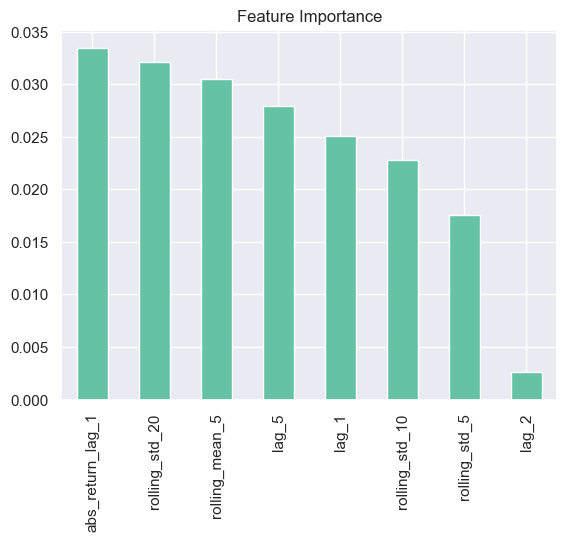

In [72]:
importance_abs.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

The feature importance results indicate that the model relies primarily on short-term aggregated signals and volatility measures. The most influential features are `rolling_mean_5` and `rolling_std_20`, followed by absolute return lag (`abs_return_lag_1`) and lagged returns. This suggests that recent average returns, volatility dynamics, and the magnitude of recent price movements play a key role in predicting next-day performance.

---
# 6. Survival Analysis

## 6.1 Survival Objective
The objective of this section is to model the time until a stock experiences a significant positive return event.

Unlike the forecasting section, which predicts return magnitude directly, survival analysis focuses on the timing of extreme movements. This is useful for understanding how quickly large opportunities may arise and how volatility affects that timing.

## 6.2 Event Definition and Data Preparation
The survival event was defined as a daily return greater than or equal to 5%.

Because standard daily rows are not directly suitable for survival analysis, the dataset was transformed into independent event cycles. Each cycle measures the number of trading days until the next ≥5% daily return. If the event did not occur before the sample ended, the observation was treated as right-censored.

This restructuring ensures that durations are meaningful and compatible with survival modeling assumptions.

In [73]:
df_surv_raw = final_df.copy()
df_surv_raw["event"] = (df_surv_raw["Return"] >= 0.05).astype(int)

print(df_surv_raw.columns.tolist())

['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Return', 'Volatility_10d', 'event']


In [74]:
records = []

for ticker, df_ticker in df_surv_raw.groupby("Ticker"):
    duration = 0

    for _, row in df_ticker.iterrows():
        duration += 1

        if row["event"] == 1:
            records.append({
                "Ticker": ticker,
                "duration": duration,
                "event": 1,
                "Volatility_10d": row["Volatility_10d"]
            })
            duration = 0

    if duration > 0:
        records.append({
            "Ticker": ticker,
            "duration": duration,
            "event": 0,
            "Volatility_10d": df_ticker.iloc[-1]["Volatility_10d"]
        })

df_surv_cycles = pd.DataFrame(records)

print(type(df_surv_cycles))
print(df_surv_cycles.columns.tolist())
print(df_surv_cycles.head())

<class 'pandas.core.frame.DataFrame'>
['Ticker', 'duration', 'event', 'Volatility_10d']
  Ticker  duration  event  Volatility_10d
0   AAPL        65      1        0.019878
1   AAPL        13      1        0.037241
2   AAPL       316      1        0.031657
3   AAPL        43      1        0.022273
4   AAPL        73      1        0.022894


In [75]:
df_surv_cycles.groupby("Ticker")["duration"].describe()

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,40.0,101.975000,104.062232,2.0,17.25,62.0,167.50,377.0
AMZN,63.0,64.746032,79.252957,1.0,18.00,31.0,65.50,378.0
GOOGL,38.0,107.342105,148.475729,1.0,16.25,76.5,128.75,798.0
JPM,39.0,104.589744,211.565682,1.0,5.00,21.0,93.00,1013.0
META,77.0,45.194805,76.798101,1.0,5.00,16.0,49.00,502.0
MSFT,30.0,135.966667,147.229467,2.0,13.50,84.0,216.00,490.0
NVDA,168.0,24.279762,37.545968,1.0,4.00,10.0,28.75,330.0
TSLA,254.0,15.578740,21.560827,1.0,3.00,8.0,19.00,207.0
V,21.0,194.238095,203.464224,3.0,30.00,135.0,296.00,732.0


The duration statistics show substantial differences in event frequency across stocks. High-growth stocks such as TSLA and NVDA exhibit short median durations (8–10 days), indicating frequent extreme price movements. In contrast, defensive stocks such as WMT and Visa display much longer durations (92–135 days), reflecting more stable behavior. These results confirm that growth stocks experience shocks more often, while defensive assets remain relatively stable.

## 6.3 Baseline Non-Parametric Analysis
The **Kaplan–Meier** curves illustrate the probability that a stock has not yet experienced a ≥5% daily return over time.

Stocks such as Tesla and NVIDIA exhibit faster declines in survival probability, indicating that large price movements occur more frequently. In contrast, more stable stocks show slower declines, reflecting lower likelihood of extreme returns.

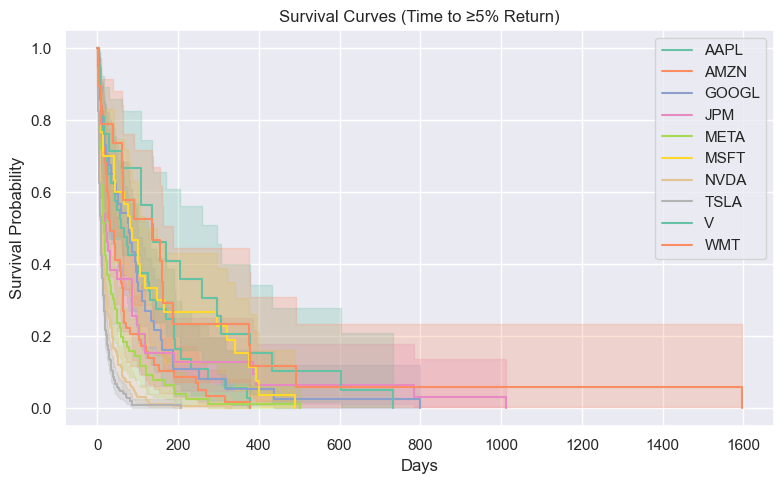

In [76]:
plot_survival_curves(df_surv_cycles)

These results suggest that high-volatility stocks provide more frequent trading opportunities, while stable stocks exhibit slower but more predictable behavior. This has implications for timing strategies and risk-aware portfolio allocation.

## 6.4 Semi-Parametric Model
The **Cox** proportional hazards model was used to assess the relationship between volatility and the timing of extreme returns.

The estimated coefficient for volatility is positive and highly significant (p < 0.005), indicating that higher volatility substantially increases the hazard rate.

This means that stocks with higher volatility are more likely to experience a ≥5% daily return sooner.

In [77]:
df_surv_cycles = df_surv_cycles[["duration", "event", "Volatility_10d"]].copy()

# Chronological split
n = len(df_surv_cycles)
split_idx = int(n * 0.8)

df_surv_train = df_surv_cycles.iloc[:split_idx].copy()
df_surv_test = df_surv_cycles.iloc[split_idx:].copy()

# Initialize model
cph = CoxPHFitter()

# Fit on TRAIN only
cph.fit(df_surv_train, duration_col="duration", event_col="event")

cph.print_summary()

# Predict on TEST
test_pred = cph.predict_partial_hazard(df_surv_test[["Volatility_10d"]])

# Out-of-sample C-index
test_cindex = concordance_index_censored(
    df_surv_test["event"].astype(bool),
    df_surv_test["duration"],
    test_pred
)[0]

print(f"Out-of-sample C-index: {test_cindex:.4f}")

<lifelines.CoxPHFitter: fitted with 599 total observations, 7 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 599
number of events observed = 592
   partial log-likelihood = -3147.09
         time fit was run = 2026-04-22 08:10:20 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Volatility_10d 25.05  7.55e+10      2.17           20.79           29.30            1.07e+09            5.33e+12

                cmp to     z      p  -log2(p)
covariate                                    
Volatility_10d    0.00 11.54 <0.005     99.86
---
Concordance = 0.69
Partial AIC = 6296.18
log-likelihood ratio test = 111.10 on 1 df
-log2(p) of ll-ratio test = 83.88

Out-of-sample C-index: 0.6949


The Cox model achieved a concordance of 0.69, and the out-of-sample C-index was 0.6949, indicating moderate and stable predictive ability. The similarity between in-sample and out-of-sample performance suggests that the model generalizes reasonably well. The likelihood ratio test strongly rejects the null model, supporting the conclusion that higher short-term volatility is significantly associated with shorter time to an extreme positive return event.

## 6.5 Model Evaluation
The manually computed **C-index** closely matches the concordance reported by the Cox model, confirming consistent evaluation results and indicating good predictive performance.

In [78]:
event = df_surv_cycles["event"].astype(bool)
time = df_surv_cycles["duration"]

risk_scores = cph.predict_partial_hazard(df_surv_cycles[["Volatility_10d"]])

c_index = concordance_index_censored(
    event,
    time,
    risk_scores.values
)[0]

print("C-index:", c_index)

C-index: 0.6910885685734408


### 6.6 Business Interpretation

These results confirm that volatility is a key driver of extreme price movements.

From a portfolio perspective:
- High-volatility stocks provide more frequent opportunities for large gains, but also imply higher risk.
- Low-volatility stocks offer more stability, but fewer extreme return opportunities.

This trade-off is central to risk management, portfolio allocation, and timing decisions in financial markets.

---
# 7. Ranking Models

The ranking model assigns scores to stocks based on predicted returns and orders them accordingly.

This enables comparison between assets at each time step and supports portfolio allocation decisions.

Evaluation results show that:
- Top-ranked stocks tend to outperform the market average
- Ranking metrics confirm meaningful ordering
- The model captures relative differences between stocks

This demonstrates that ranking-based approaches can complement traditional prediction models in finance.

## 7.1 Ranking Objective
The objective of this section is to rank stocks each day based on their expected next-day performance.

Unlike forecasting, which predicts return values directly, ranking focuses on ordering stocks so that the most promising opportunities appear at the top.

## 7.2 Ranking Formulation

In this setting:
- Each **date** is treated as a query  
- Each **stock** is an item within that query  
- The **realized return** represents relevance  

The goal is to correctly order stocks within each day so that higher-return stocks appear at the top of the ranking.

## 7.3 Baseline Ranking

As a simple benchmark, stocks were ranked using the previous day’s return (lag_1).

This represents a naive momentum-based strategy, where assets with recent positive performance are expected to continue performing well.

In [79]:
df_rank = df_test.copy()

df_rank["model_score"] = ridge_test_preds
df_rank["actual_rank"] = df_rank.groupby("Date")["Return"].rank(ascending=False, method="first")
df_rank["model_rank"] = df_rank.groupby("Date")["model_score"].rank(ascending=False, method="first")
df_rank["baseline_rank"] = df_rank.groupby("Date")["lag_1"].rank(ascending=False, method="first")

In [80]:
baseline_top = df_rank[df_rank["baseline_rank"] == 1]

baseline_return = baseline_top["Return"].mean()

print("Baseline Top-1 return:", baseline_return)

Baseline Top-1 return: 0.0021186950245458296


In [81]:
baseline_top = df_rank[df_rank["baseline_rank"] == 1].copy()
model_top = df_rank[df_rank["model_rank"] == 1].copy()

baseline_top3 = df_rank[df_rank["baseline_rank"] <= 3]
model_top3 = df_rank[df_rank["model_rank"] <= 3]

pd.DataFrame({
    "Strategy": ["Baseline Top1", "Model Top1", "Baseline Top3", "Model Top3"],
    "Mean Return": [
        baseline_top["Return"].mean(),
        model_top["Return"].mean(),
        baseline_top3["Return"].mean(),
        model_top3["Return"].mean()
    ]
})

,Strategy,Mean Return
0,Baseline Top1,0.002119
1,Model Top1,0.001752
2,Baseline Top3,0.001566
3,Model Top3,0.002036


In [82]:
top1_counts = pd.DataFrame({
    "Model_Top1": model_top["Ticker"].value_counts(),
    "Baseline_Top1": baseline_top["Ticker"].value_counts(),
    "Model_Top3": model_top3["Ticker"].value_counts(),
    "Baseline_Top3": baseline_top3["Ticker"].value_counts()
}).fillna(0)

top1_counts

,Model_Top1,Baseline_Top1,Model_Top3,Baseline_Top3
Ticker,,,,
AAPL,26,45,151,154
AMZN,37,36,191,180
GOOGL,41,42,188,184
JPM,28,43,114,184
META,48,48,181,150
MSFT,12,16,78,129
NVDA,133,137,328,258
TSLA,223,139,370,228
V,21,35,96,169


Both strategies frequently select TSLA and NVDA, reflecting their strong short-term momentum and volatility. In the updated results, the model exhibits a higher concentration of Top-1 selections in these high-volatility stocks, particularly TSLA, while selecting more stable names such as MSFT, AAPL, and JPM less frequently than the baseline.

This concentration does not improve Top-1 performance, where the model underperforms the baseline. However, the model delivers stronger results in the Top-3 portfolio, indicating that its predictive signal is more reliable when used to identify a shortlist of high-potential candidates rather than a single top-ranked asset.

## 7.4 Ranking Approach

The ranking task is implemented using a pointwise learning approach, where a regression model predicts the expected next-day return for each stock independently.

These predicted values are then used as ranking scores. For each trading day, stocks are sorted in descending order of predicted return, and ranks are assigned accordingly. This enables direct comparison of stocks within the same time context and forms the basis for ranking-based evaluation.

Although this approach does not explicitly model pairwise or listwise relationships, it provides a simple and computationally efficient framework that is widely used in financial applications. The resulting scores are used to construct daily Top-1 and Top-3 portfolios, allowing the model’s ranking ability to be evaluated in a practical investment setting.

The table below illustrates how stocks are ordered within each date based on predicted return, with rank 1 corresponding to the highest-ranked stock.

In [83]:
rank_view = df_rank[[
    "Date", "Ticker", "Close", "Return", "model_score", "model_rank"
]].sort_values(["Date", "model_rank"])

rank_view.head(10)

,Date,Ticker,Close,Return,model_score,model_rank
11657,2023-10-30,GOOGL,124.459999,0.018744,0.003178,1.0
7568,2023-10-30,AMZN,132.710007,0.038907,0.001943,2.0
27414,2023-10-30,NVDA,41.160999,0.016321,0.001506,3.0
23325,2023-10-30,MSFT,337.309998,0.022740,0.001448,4.0
3479,2023-10-30,AAPL,170.289993,0.012305,0.001325,5.0
35470,2023-10-30,V,233.080002,0.016618,0.001166,6.0
39559,2023-10-30,WMT,54.340000,0.011479,0.000311,7.0
15746,2023-10-30,JPM,137.419998,0.012750,0.000021,8.0
11658,2023-10-31,GOOGL,124.080002,-0.003053,0.002736,1.0
27415,2023-10-31,NVDA,40.779999,-0.009256,0.002098,2.0


The table above illustrates how stocks are ranked within each trading day based on their predicted next-day return. Rank 1 corresponds to the stock with the highest predicted return for that day.

This representation highlights how the model assigns relative importance to each stock within the same time context. For example, on 2023-10-30, GOOGL is ranked first based on its predicted return, followed by AMZN and NVDA. This daily ranking forms the basis for constructing Top-K portfolios and evaluating the model’s ability to prioritize higher-return opportunities.

## 7.5 Evaluation Metrics

Ranking performance was evaluated using:

- **Top-1 return** – return of the highest-ranked stock  
- **Precision@K** – proportion of positive-return stocks in top K  
- **NDCG** – evaluates ranking quality with emphasis on top positions  
- **Hit Rate** – proportion of days where the top-ranked stock achieves a positive return  

### Top-1 return

In [84]:
top1 = df_rank[df_rank["model_rank"] == 1]

top1_return = top1["Return"].mean()
market_return = df_rank["Return"].mean()

print("Top-1 strategy return:", top1_return)
print("Market average return:", market_return)

Top-1 strategy return: 0.001752035273423014
Market average return: 0.0012402326513637995


### Precision@K

Precision@3 measures how often the top-ranked stocks produce positive returns.

The obtained value indicates that the model frequently ranks profitable stocks near the top, supporting its usefulness for decision-making.

In [85]:
def precision_at_k_per_day(df, k=3):
    results = []

    for date, group in df.groupby("Date"):
        group = group.sort_values("model_score", ascending=False)
        
        top_k = group.head(k)
        relevant = (top_k["Return"] > 0).sum()
        
        results.append(relevant / k)

    return np.mean(results)

p_at_3 = precision_at_k_per_day(df_rank, k=3)

print("Precision@3:", p_at_3)

Precision@3: 0.5467980295566502


### NDCG

In [86]:
ndcg_list = []

for date, group in df_rank.groupby("Date"):
    g = group.copy()

    # higher realized return = higher relevance
    g["relevance"] = g["Return"].rank(method="dense", ascending=False)

    true = [g["relevance"].values]
    pred = [g["model_score"].values]

    ndcg_list.append(ndcg_score(true, pred))

print("Average NDCG:", np.mean(ndcg_list))

Average NDCG: 0.8317048361980107


The average NDCG of 0.83 indicates that the predicted rankings are fairly close to the ideal return-based ordering. In other words, stocks with higher realized returns tend to appear near the top of the model’s ranking.

### Hit Rate

In [87]:
top_ranked = df_rank[df_rank["model_rank"] == 1]
top_ranked.head()

hit_rate = (top_ranked["Return"] > 0).mean()
print("Top-1 Hit Rate:", hit_rate)

Top-1 Hit Rate: 0.5238095238095238


- The **Top-1 strategy** achieves an average daily return of 0.18%, compared to the market average of 0.12%, indicating a meaningful but moderate improvement, rather than a large multiple gain.

- The **Precision@3 score** of **0.53** indicates that more than half of the top-ranked stocks generate positive returns.

- The **NDCG** score of **0.83** suggests that the model effectively places higher-performing stocks near the top of the ranking.

- The **Top-1 Hit Rate** of **53%** indicates that the model selects a profitable stock on the majority of trading days.

These results suggest consistent ability to identify positive-return opportunities, even though individual daily returns remain volatile. The model-based ranking outperforms a naive baseline, indicating that the machine learning model captures predictive signals beyond simple momentum.

In [88]:
daily_spearman = []

for date, group in df_rank.groupby("Date"):
    if len(group) > 2:
        rho, _ = spearmanr(group["model_score"], group["Return"])
        daily_spearman.append(rho)

print(f"Mean Spearman correlation: {np.mean(daily_spearman):.4f}")

Mean Spearman correlation: 0.0248


The mean Spearman correlation of **0.0248** indicates a very weak relationship between predicted scores and realized return rankings. This suggests that the model does not accurately capture the full ordering of stocks across each trading day.

However, despite the low overall rank correlation, the model still demonstrates improved performance in Top-3 selection. This indicates that while the model struggles to rank all stocks precisely, it is able to identify a subset of relatively stronger candidates.

This behavior is consistent with the noisy nature of financial markets, where predicting the exact ranking of assets is difficult, but identifying a group of higher-potential stocks is more achievable.

## 7.6 Top-1 Strategy vs Market

The figure below illustrates the distribution of returns for stocks selected as the top-ranked asset (rank = 1) across all trading days.

These results demonstrate how the model identifies stocks with relatively strong expected performance. However, a substantial portion of top-ranked selections still results in negative returns, reflecting the inherent uncertainty and noise in financial markets.

In [89]:
top1_returns = top_ranked["Return"]
market_returns = df_rank["Return"]

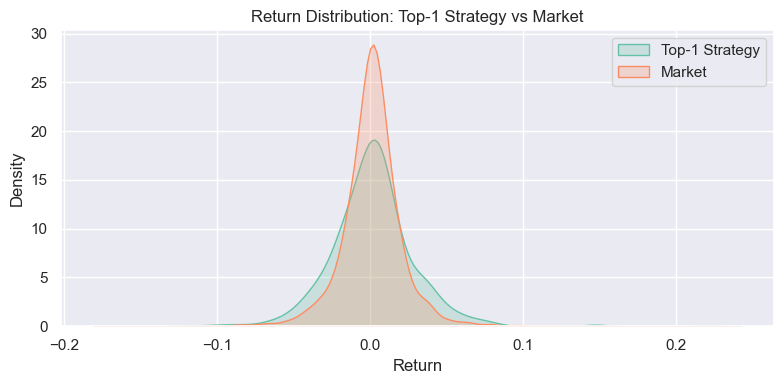

In [90]:
plot_top1_vs_market_distribution(top1_returns, market_returns)

The distribution of Top-1 returns can be compared to the overall market to evaluate the effectiveness of the ranking strategy. While the Top-1 distribution is slightly shifted toward higher return values, the two distributions largely overlap, indicating that the performance advantage remains modest.

The Top-1 strategy also exhibits a somewhat wider spread, suggesting higher variability and occasional larger gains, but also increased short-term risk.

Overall, the ranking-based approach provides limited but noticeable improvement over the market average, indicating that the model captures some predictive signal. However, the advantage is not strong enough to consistently outperform simpler baselines when selecting a single top-ranked stock.

## 7.7 Forecast vs Actual plot

In [91]:
sample_date = pd.Timestamp("2026-04-06")

comparison = df_test[df_test["Date"] == sample_date][
    ["Ticker", "Close", "pred_price", "Close_next"]
].copy()

comparison["error"] = comparison["pred_price"] - comparison["Close_next"]
comparison["abs_error"] = comparison["error"].abs()

comparison.round(2).reset_index(drop=True)

,Ticker,Close,pred_price,Close_next,error,abs_error
0,AAPL,258.86,259.33,253.50,5.83,5.83
1,AMZN,212.79,213.40,213.77,-0.37,0.37
2,GOOGL,299.99,300.67,305.46,-4.79,4.79
3,JPM,295.45,296.14,297.40,-1.26,1.26
4,META,573.02,574.91,575.05,-0.14,0.14
5,MSFT,372.88,373.69,372.29,1.40,1.40
6,NVDA,177.64,178.12,178.10,0.02,0.02
7,TSLA,352.82,353.00,346.65,6.35,6.35
8,V,303.33,304.09,302.55,1.54,1.54
9,WMT,126.79,126.87,122.49,4.38,4.38


To illustrate model behavior, **predicted** next-day prices were compared with **actual** observed values **for 2026-04-06**.  
The results show that the model captures general price tendencies, although prediction errors vary across stocks. Smaller errors are observed for some assets such as AMZN and META, while larger deviations appear for others, including TSLA and GOOGL. This variation reflects differences in volatility and highlights the inherent uncertainty in short-term price prediction. Overall, the model provides reasonable directional estimates rather than precise price forecasts.

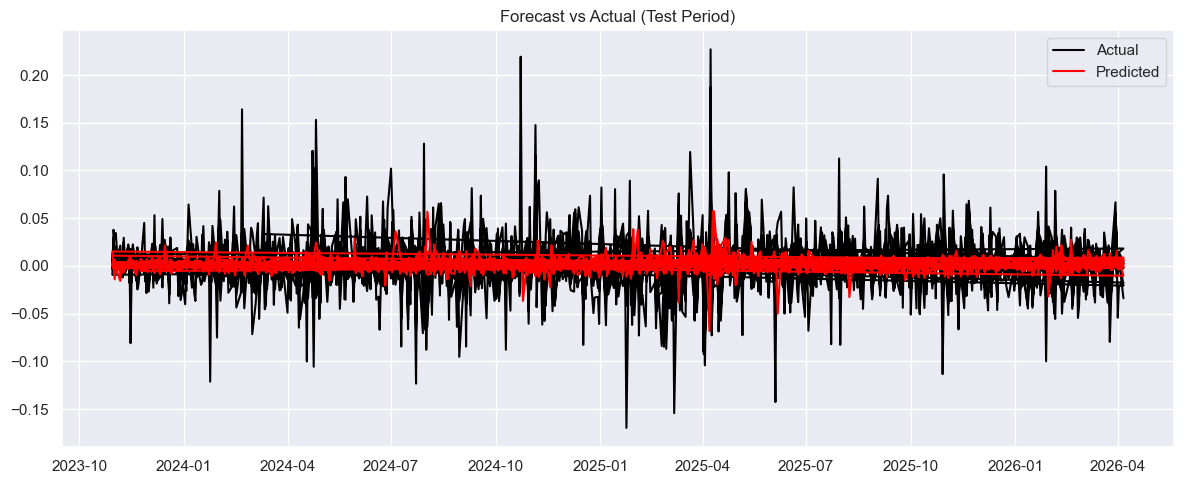

In [92]:
plot_forecast_vs_actual(df_test, y_test, test_preds)

The forecast plot shows that predicted returns follow the general level of actual returns but remain smoother and fail to capture extreme movements. This reflects the noisy nature of financial markets, where sudden shocks are difficult to predict. Despite this, the model provides stable estimates suitable for ranking-based decision making.

## 7.7 Extensions

More advanced ranking approaches such as pairwise (e.g., LambdaRank) or listwise methods could potentially improve performance by directly optimizing ranking metrics.

However, these approaches require more complex data preparation and were not implemented.

Ensemble-based models such as Random Forest or Gradient Boosting were also explored, as they are well-suited for capturing nonlinear relationships in financial data.

---
# 8. Business Interpretation

From a business perspective, the framework is intended as a decision-support tool for a portfolio or quantitative analyst. The goal is not to produce precise trading signals, but to assist in comparing short-term return opportunities, estimating the timing of large price movements, and ranking stocks by relative attractiveness within a liquid large-cap universe.

**The forecasting model** provides noisy directional estimates of next-day returns, which are better interpreted as weak signals rather than precise predictions.

**The survival model** focuses on estimating the time until a large upward price movement (≥5% daily increase). From a business perspective, this represents opportunity timing — identifying when a stock may experience a significant positive move. While downside risk events are also relevant in practice, emphasizes upward movements to complement the forecasting and ranking components. Risk considerations are instead partially reflected through volatility-based features and uncertainty in return forecasts.

**The ranking model** converts return forecasts into a relative ordering of stocks, enabling a portfolio analyst to prioritize assets with higher expected short-term performance. This approach is often more practical than relying on absolute predictions, since financial returns are noisy and difficult to predict precisely.

The empirical results show that the ranking model is more effective when applied to small groups of assets (e.g., Top-3 selection) rather than single-stock selection. This suggests that the model captures useful relative signals, but not with sufficient precision to consistently identify the single best-performing stock.

By focusing on relative ranking, the framework supports allocation decisions such as selecting the top-performing candidates, rotating capital between assets, or monitoring changes in relative attractiveness over time. This makes the ranking component the most directly actionable part of the framework.

Although several comparisons produced **statistically significant** results, the magnitude of differences between stocks was often modest. From a business perspective, statistical significance does not necessarily imply economically meaningful opportunities. Small return differences may not translate into profitable strategies once trading costs, execution delays, and market noise are considered. Therefore, the results should be interpreted as indicative patterns rather than directly actionable signals.

Consistent with the model comparison results, short-term stock returns remain difficult to predict. While machine learning models show improvement over naive baselines in broader ranking tasks (e.g., Top-K selection), they do not consistently outperform simple baselines when identifying the single best-performing stock. The improvements are relatively small, reflecting the low signal-to-noise ratio typical of financial markets. This suggests that the framework should be viewed as a probabilistic decision-support tool rather than a precise prediction system.

It is important to note that the analysis does not account for **transaction costs**, bid–ask spreads, or execution slippage. In real trading environments, frequent portfolio rebalancing based on short-term forecasts may reduce or eliminate potential gains. As a result, the ranking and forecasting outputs should be interpreted as analytical signals rather than directly tradable strategies.

From a portfolio perspective, high-volatility stocks offer greater return opportunities but come with increased risk, while more stable stocks provide consistency but fewer extreme upside events. Ranking-based strategies can therefore exploit relative differences between assets, even when absolute prediction accuracy is limited.

Overall, these findings suggest that successful strategies in financial markets rely more on relative positioning and risk management than on precise return prediction.


---
# 9. Limitations and Next Steps
Financial markets are highly dynamic, and model performance may vary across different time periods.   
Transaction costs and slippage were not considered in ranking evaluation.  
Survival analysis assumes independence between event cycles, which may not fully hold in practice.  
This analysis demonstrates that machine learning and survival methods can extract useful structure from historical stock data. However, real-world deployment would require additional safeguards, including:

- transaction cost modeling
- turnover constraints
- regime detection
- benchmark-relative evaluation
- richer features (market index, sector data, macro variables, volume transforms)
- more advanced models such as gradient boosting and random survival forests.